# **Notebook Kerja Tim Data Scientist**
- **Tim:** CC26-PSU200
- **Raw Dataset:** "Disease and symptoms dataset.csv"
- **Tautan Dataset:** https://data.mendeley.com/datasets/2cxccsxydc/1

## **Fase 0: Setup & Import Library**

### **Import Library**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive integration
from google.colab import drive

# JSON for dictionary export
import json

# Set style untuk visualisasi yang lebih baik
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Untuk menampilkan semua kolom saat display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

**Penjelasan:** Tahap ini dilakukan *importing library* untuk manipulasi data ('pandas', 'numpy'), visualisasi ('matplotlib', 'seaborn'), integrasi *cloud storage* ('google.colab'), serta manajemen format file ('json'). Di sini juga dilakukan konfigurasi pengaturan visualisasi menggunakan gaya 'seaborn-v0_8-whitegrid' serta memaksimalkan batas kolom visualisasi agar tidak terpotong saat dianalisis.


### **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Penjelasan:** Kemudian mengintegrasikan ruang penyimpanan Google Drive ke dalam *environtment* Google Colab untuk mengakses file dataset mentah secara langsung tanpa harus mengunggah berulang secara lokal.

### **Load & Optimasi Dataset**

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/DS_CC26-PSU200/Raw Dataset/Disease and symptoms dataset.csv')
# Optimasi tipe data int8 untuk efisiensi memori (Data Biner)
cols_biner = df_raw.columns.drop('diseases')
df_raw[cols_biner] = df_raw[cols_biner].apply(pd.to_numeric, downcast='integer')

print(f"\nDataset Awal : {df_raw.shape} | Memory: {df_raw.memory_usage().sum()/1024**2:.2f} MB")
display(df_raw.head())



Dataset Awal : (246945, 378) | Memory: 90.67 MB


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling h

- **Penjelasan:** Tahap ini memuat file 'Disease and symptoms dataset.csv'. Setelah dimuat, tipe data pada seluruh kolom biner (gejala) dioptimalkan (*downcasting*) menjadi 'int8' menggunakan 'pd.to_numeric'.


- **Insight:** Dataset mentah memiliki 246.945 baris dan 378 kolom dengan penggunaan memori sebesar 90.67 MB. Dataset ini bertipe matriks biner di mana angka 1 menunjukkan keberadaan gejala dan angka 0 menunjukkan ketiadaan gejala pada suatu penyakit.

## **Fase 1: Assessing Data & EDA Awal**

### **Deep Assessing Report**

In [ ]:
def deep_assessing(df, name="Dataset"):
    print(f"=== ASSESSING REPORT: {name} ===")
    print(f"1. Bentuk Data (Shape): {df.shape}")
    print(f"2. Total Duplikat: {df.duplicated().sum()} baris")
    print(f"3. Total Missing Values: {df.isnull().sum().sum()} sel")

    # Cek tipe data
    tipe_data = df.dtypes.value_counts()
    print(f"4. Tipe Data:\n{tipe_data.to_string()}")

    # Cek baris kosong gejala
    symptom_cols = df.columns.drop('diseases', errors='ignore')
    zero_symptom_rows = (df[symptom_cols].sum(axis=1) == 0).sum()
    print(f"5. Baris dengan 0 Gejala: {zero_symptom_rows}")
    print(f"6. Jumlah Penyakit Unik: {df['diseases'].nunique()}")
    print("-" * 35)

deep_assessing(df_raw, "Dataset Awal")

=== ASSESSING REPORT: Dataset Awal ===
1. Bentuk Data (Shape): (246945, 378)
2. Total Duplikat: 57298 baris
3. Total Missing Values: 0 sel
4. Tipe Data:
int8      377
object      1
5. Baris dengan 0 Gejala: 0
6. Jumlah Penyakit Unik: 773
-----------------------------------


- **Penjelasan:** Dibuat fungsi modular 'deep_assessing' untuk melakukan audit otomatis terhadap kualitas data. Fungsi ini memeriksa bentuk data (*shape*), total baris duplikat, *missing values*, sebaran tipe data, serta menghitung baris yang tidak memiliki gejala sama sekali (baris bernilai 0 di semua kolom gejala).
- **Insight:**

    - Dataset berukuran 246.945 baris, 378 kolom.
    - Ditemukan 57.298 baris duplikat.
    - Data bersih dari *null/NaN values*.
    - 377 kolom bernilai 'int8' (fitur gejala) dan 1 kolom bernilai 'object' (label nama penyakit).
    - Tidak ada sampel/baris yang kosong tanpa gejala.
    - Terdapat 773 penyakit unik di dalam dataset mentah ini.

### **Distribusi Penyakit Awal (Visualisasi)**

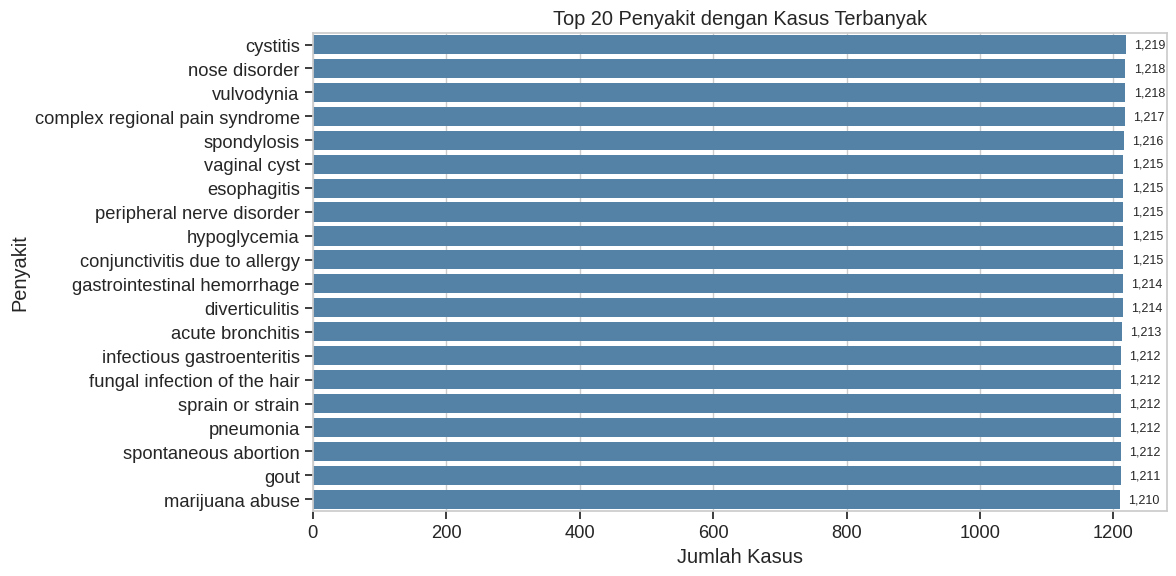


Total penyakit unik di awal: 773
Penyakit dengan kasus terbanyak: 'cystitis' (1,219 kasus)
Penyakit dengan kasus tersedikit: 'kaposi sarcoma' (1 kasus)


In [ ]:
# Top 20 penyakit terbanyak
disease_counts = df_raw['diseases'].value_counts()
top20_diseases = disease_counts.head(20)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top20_diseases.values, y=top20_diseases.index, color='steelblue')

# Menambahkan label angka di ujung setiap bar
for i, (nilai, nama) in enumerate(zip(top20_diseases.values, top20_diseases.index)):
    ax.text(nilai + (nilai * 0.01), i, f'{nilai:,}',
            va='center', ha='left', fontsize=9)

plt.xlabel('Jumlah Kasus')
plt.ylabel('Penyakit')
plt.title('Top 20 Penyakit dengan Kasus Terbanyak')
plt.tight_layout()
plt.show()

print(f"\nTotal penyakit unik di awal: {len(disease_counts)}")
print(f"Penyakit dengan kasus terbanyak: '{disease_counts.index[0]}' ({disease_counts.iloc[0]:,} kasus)")
print(f"Penyakit dengan kasus tersedikit: '{disease_counts.index[-1]}' (1 kasus)")

- **Penjelasan:** Digunakan diagaram batang horizontal untuk memetekan 20 jenis penyakit dengan frekuensi kemunculan tertinggi di dalam dataset mentah/asli.
- **Insight**: Dataset ini menunjukkan ketimpangan kelas (*class imbalanced*) yang ekstrem. Di mana penyakit teratas memiliki ribuan sampel, sementara ada penyakit di ekor distribusi yang hanya memiliki 1 sampel saja.

### **Distribusi Jumlah Gejala per Baris (EDA Awal)**

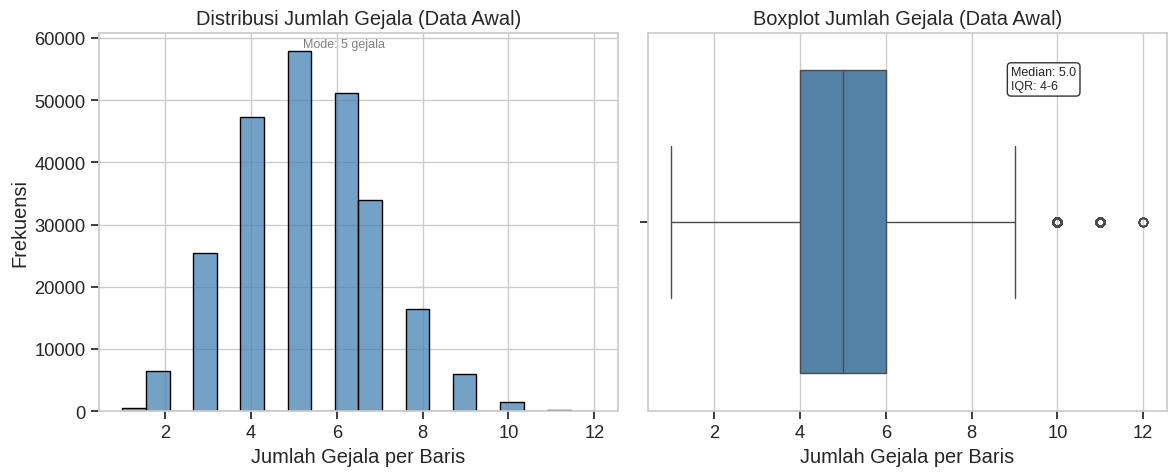

Statistik jumlah gejala per baris (Data Awal):
count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          12.000000
dtype: float64

Persentase baris dengan gejala <3: 2.79%


In [ ]:
# Hitung jumlah gejala per baris di data awal
gejala_cols_awal = df_raw.columns.drop('diseases')
n_gejala_awal = df_raw[gejala_cols_awal].sum(axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(n_gejala_awal, bins=20, color='steelblue')  # hapus edgecolor
plt.xlabel('Jumlah Gejala per Baris')
plt.ylabel('Frekuensi')
plt.title('Distribusi Jumlah Gejala (Data Awal)')

# Tambahkan label nilai pada batang tertinggi untuk konteks
max_freq = n_gejala_awal.value_counts().sort_index().max()
max_bin = n_gejala_awal.value_counts().sort_index().idxmax()
plt.text(max_bin + 0.2, max_freq, f'Mode: {max_bin} gejala', va='bottom', fontsize=9, color='gray')

plt.subplot(1, 2, 2)
sns.boxplot(x=n_gejala_awal, color='steelblue')  # warna konsisten
plt.xlabel('Jumlah Gejala per Baris')
plt.title('Boxplot Jumlah Gejala (Data Awal)')

# Tambahkan statistik ringkas pada plot
median_val = n_gejala_awal.median()
q1_val = n_gejala_awal.quantile(0.25)
q3_val = n_gejala_awal.quantile(0.75)
plt.annotate(f'Median: {median_val}\nIQR: {q1_val:.0f}-{q3_val:.0f}',
             xy=(0.7, 0.85), xycoords='axes fraction', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Statistik jumlah gejala per baris (Data Awal):")
print(n_gejala_awal.describe())
print(f"\nPersentase baris dengan gejala <3: {(n_gejala_awal < 3).mean() * 100:.2f}%")

- **Penjelasan:** Dilakukan penghitungan total gejala yang aktif pada tiap baris dengan menjumlahkan nilai biner (1) di semua kolom gejala (mengecualikan kolom target/label). Distribusi datanya divisualisasikan menggunakan Histogram (untuk lihat sebaran dan nilai modus) dan Boxplot (identifikasi rentang interkuartil & pencilan) yang dilengkapi dengan anotasi statistik serta ringkasan deskriptif melalui '.describe()'.
- **Insight:**
  - Mayoritas orang/pasien dalam dataset mengeluhkan 4-6 gejala sekaligus, dengan median dan modus berada pada angka 5 gejala per baris.
  - Meskipun batas max gejala mencapai 12 gejala, terdapat sekitar 2,79% baris data (anomali minoritas) di mana pasien hanya mmeiliki <3 gejala, bahkan ada yang hanya menderita 1 gejala.

### **Pertanyaan Bisnis**

In [ ]:
print("="*60)
print("PERTANYAAN BISNIS YANG DAPAT DIUKUR")
print("="*60)

questions = [
    "1. Berapa banyak penyakit langka (<50 kasus) yang perlu dihapus?",
    "2. Bagaimana distribusi jumlah gejala per penyakit?",
    "3. Penyakit apa yang memiliki pola gejala paling unik (sedikit overlap)?",
    "4. Gejala apa yang paling sering muncul dan bersifat general?",
    "5. Setelah cleaning, berapa penyakit yang memiliki minimal 3 gejala?"
]

for q in questions:
    print(q)

print("\n" + "="*60)
print("HIPOTESIS AWAL")
print("="*60)
print("- Data memiliki banyak penyakit minor yang akan mengganggu performa model")
print("- Sebagian kecil baris memiliki gejala <3 yang perlu ditangani")
print("- Setelah cleaning, dataset akan lebih seimbang dan siap untuk modeling")

PERTANYAAN BISNIS YANG DAPAT DIUKUR
1. Berapa banyak penyakit langka (<50 kasus) yang perlu dihapus?
2. Bagaimana distribusi jumlah gejala per penyakit?
3. Penyakit apa yang memiliki pola gejala paling unik (sedikit overlap)?
4. Gejala apa yang paling sering muncul dan bersifat general?
5. Setelah cleaning, berapa penyakit yang memiliki minimal 3 gejala?

HIPOTESIS AWAL
- Data memiliki banyak penyakit minor yang akan mengganggu performa model
- Sebagian kecil baris memiliki gejala <3 yang perlu ditangani
- Setelah cleaning, dataset akan lebih seimbang dan siap untuk modeling


## **Fase 2: Cleaning Data**

### **Menghapus Duplikat**

In [ ]:
# Hapus semua baris duplikat
df_clean = df_raw.drop_duplicates()

print(f"Jumlah baris sebelum: {len(df_raw):,}")
print(f"Jumlah baris setelah: {len(df_clean):,}")
print(f"Jumlah duplikat yang dihapus: {len(df_raw) - len(df_clean):,}")

Jumlah baris sebelum: 246,945
Jumlah baris setelah: 189,647
Jumlah duplikat yang dihapus: 57,298


- **Penjelasan:** Dilakukan pembersihan data dengan membuang 57.298 baris data duplikat menggunakan fungsi '.drop_duplicates()'.
- **Insight:** Setelah duplikat dihapus, ukuran dataset berkurang menjadi 189.647 baris.

### **Identifikasi Penyakit Minor (<50 kasus)**

In [ ]:
# Tampilkan penyakit dengan frekuensi <50
rare_before = df_clean['diseases'].value_counts()[df_clean['diseases'].value_counts() < 50]
print(f"Jumlah penyakit dengan kasus <50: {len(rare_before)}")
print("\nContoh 10 penyakit minor:")
print(rare_before.head(10))

Jumlah penyakit dengan kasus <50: 360

Contoh 10 penyakit minor:
diseases
thoracic outlet syndrome                      48
retinopathy due to high blood pressure        47
cerebral palsy                                47
chlamydia                                     47
lung cancer                                   47
peripheral arterial embolism                  47
polymyalgia rheumatica                        47
systemic lupus erythematosis (sle)            46
poisoning due to sedatives                    46
foreign body in the gastrointestinal tract    45
Name: count, dtype: int64


- **Penjelasan:** Dilakukan identifikasi dan isolasi kelas-kelas penyakit minor yang frekuensi kemunculannya <50 setelah proses drop duplikat. Dihitung frekuensi tiap penyakit menggunakan '.value_counts()', kemudian difilter dengan kondisi bolean indexing '<50', lalu ditampilkan total jumlah penyakit terdampak.
- **Insight:**
   - Terdapat 360 penyakit unik yang sampelnya <50.
   - Artinya sebaran data pada dataset ini memiliki *long-tail distribution*, di mana sebagian besar variasi penyakit justru kekurangan representasi data yang masif.

### **Visualisasi Penyakit Minor**


Detail Distribusi Penyakit dengan Kasus <50:
----------------------------------------
Frekuensi Kasus      Jumlah Penyakit
----------------------------------------
1                    46             
2                    29             
3                    26             
4                    14             
5                    11             
6                    20             
7                    13             
8                    20             
9                    7              
10                   8              
11                   6              
12                   9              
13                   12             
14                   6              
15                   7              
16                   8              
17                   6              
18                   6              
19                   7              
20                   3              
21                   3              
22                   3              
23                   

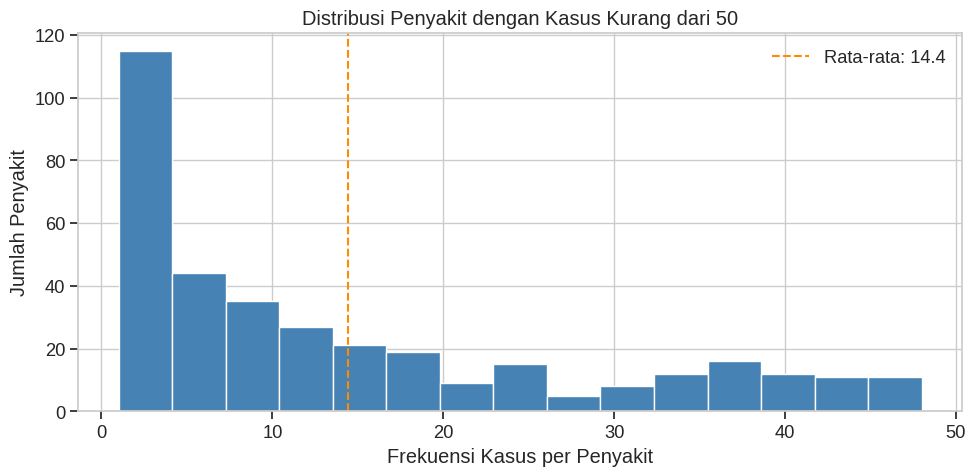


Ringkasan Statistik:
   Rata-rata: 14.4 kasus
   Median: 9 kasus
   Min: 1 kasus
   Max: 48 kasus


In [ ]:
# Kombinasi: tabel detail + histogram ringkasan
disease_counts_clean = df_clean['diseases'].value_counts()
low_freq = disease_counts_clean[disease_counts_clean < 50]

# Hitung distribusi per nilai unik untuk tabel
low_freq_counts = low_freq.value_counts().sort_index()

# Tampilkan tabel terlebih dahulu
print("\nDetail Distribusi Penyakit dengan Kasus <50:")
print("-" * 40)
print(f"{'Frekuensi Kasus':<20} {'Jumlah Penyakit':<15}")
print("-" * 40)
for freq, count in low_freq_counts.items():
    print(f"{freq:<20} {count:<15}")
print("-" * 40)
print(f"Total: {len(low_freq)} penyakit")

# Kemudian histogram untuk visualisasi pola
plt.figure(figsize=(10, 5))
plt.hist(low_freq, bins=15, color='steelblue', edgecolor='white')
plt.xlabel('Frekuensi Kasus per Penyakit')
plt.ylabel('Jumlah Penyakit')
plt.title('Distribusi Penyakit dengan Kasus Kurang dari 50')
plt.axvline(x=low_freq.mean(), color='darkorange', linestyle='--',
            label=f'Rata-rata: {low_freq.mean():.1f}')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"\nRingkasan Statistik:")
print(f"   Rata-rata: {low_freq.mean():.1f} kasus")
print(f"   Median: {low_freq.median():.0f} kasus")
print(f"   Min: {low_freq.min()} kasus")
print(f"   Max: {low_freq.max()} kasus")

- **Penjelasan:** Dilakukan visualisasi hybrid yang menggabungkan tabel frekuensi dengan grafik histogram untuk membedah sebaran 360 kelas penyakit minor. Perulangan 'for', mengalkulasi berapa banyak penyakit unik yang menempati tiap titik frekuensi (1-48 sampel), lalu divisualisasikan ke dalam histogram untuk menangkap sebaran datanya, serta ringkasan statistik deskriptif.
- **Insight:**
  - Terungkap adanya ketimpangan tinggi dan *positively skewed*.
  - Nilai median berada di angka 9 sampel/kasus, menunjukkan setengah penyakit minor bahkan tidak sampai 10 sampel.
  - Terungkap juga terdapat 46 jenis penyakit yang hanya memiliki 1 sampel di seluruh dataset, disusul 29 penyakit dengan hanay 2 kasus, menjadi kontributor utama rendahnya nilai mean sebesar 14,4 sampel.

### **Hapus Penyakit Minor**

In [ ]:
# Filter dan assessment
rare_diseases = df_clean['diseases'].value_counts()[df_clean['diseases'].value_counts() < 50].index

print(f"Sebelum: {len(df_clean)} baris, {df_clean['diseases'].nunique()} penyakit")
print(f"Menghapus {len(rare_diseases)} penyakit langka (total {(df_clean['diseases'].isin(rare_diseases)).sum():,} baris)")

df_clean = df_clean[~df_clean['diseases'].isin(rare_diseases)]

print(f"Sesudah: {len(df_clean)} baris, {df_clean['diseases'].nunique()} penyakit")
print(f"Min sampel sekarang: {df_clean['diseases'].value_counts().min()}")

Sebelum: 189647 baris, 773 penyakit
Menghapus 360 penyakit langka (total 5,193 baris)
Sesudah: 184454 baris, 413 penyakit
Min sampel sekarang: 50


- **Penjelasan:** Dilakukan penghapusan jenis penyakit minor (<50 sampel). Proses eliminasi dilakukan dengan operasi '~' dikombinasikan dengan metode '.isin(rare_diseases)'. Juga disertakan fungsi audit sebelum dan sesudah eliminasi untuk memantau perubahan jumlah baris data, penyakit unik, serta memastikan batas minimum sampel penyakit di dalam dataset.
- **Insight:**
  - Berhasil mengeliminasi 5.193 baris data dari 360 penyakit minor.
  - Ukuran dataset menjadi 184.454 baris dengan jumlah penyakit unik 413 penyakit.

### **Identifikasi Kolom Gejala & Hitung n_gejala**

In [ ]:
# Identifikasi kolom gejala
gejala_columns = [col for col in df_clean.columns if col != 'diseases']
print(f"Jumlah kolom gejala: {len(gejala_columns)}")

# Hitung jumlah gejala untuk setiap baris
df_clean = df_clean.copy()
df_clean['n_gejala'] = df_clean[gejala_columns].sum(axis=1)

print("\nStatistik jumlah gejala per baris (setelah hapus penyakit minor):")
print(df_clean['n_gejala'].describe())

Jumlah kolom gejala: 377

Statistik jumlah gejala per baris (setelah hapus penyakit minor):
count    184454.000000
mean          5.470047
std           1.652181
min           1.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          12.000000
Name: n_gejala, dtype: float64


- **Penjelasan:** Dilakukan isolasi seluruh fitur gejala dengan cara menyaring dan mengeluarkan kolom target dari 'df_clean'. Lalu mengidentifikasi 377 kolom gejala, dan dibuat salinan data untuk menghindari eror. Kemudian dihitung akumulasi kemunculan angka biner (1) pada tiap baris ke dalam kolom baru bernama 'n_gejala'. Terakhir, ditampilkan ringkasan statistik deskriptif dari kolom tersebut.
- **Insight:**
  - Rata-rata gejala yang diderita sedikit meningkat menjadi 5,47 gejala per baris dengan nilai median stabil di angka 5 gejala.
  - Meskipun begitu, nilai minimum statistik menunjukkan bahwa masih terdapat baris yang hanya mencatat 1 gejala aktif, sementara nilai maksimumnya mencapai 12 gejala.

### **Assessment Gejala <3**

In [ ]:
baris_kurang_gejala = df_clean[df_clean['n_gejala'] < 3]

print("="*50)
print("ASSESSMENT SEBELUM PENGGABUNGAN")
print("="*50)
print(f"Total baris: {len(df_clean):,}")
print(f"Baris dengan gejala >=3: {len(df_clean) - len(baris_kurang_gejala):,}")
print(f"Baris dengan gejala <3: {len(baris_kurang_gejala):,}")
print(f"Persentase baris <3: {len(baris_kurang_gejala)/len(df_clean)*100:.2f}%")
print(f"\nJumlah penyakit unik pada baris <3: {baris_kurang_gejala['diseases'].nunique()}")

ASSESSMENT SEBELUM PENGGABUNGAN
Total baris: 184,454
Baris dengan gejala >=3: 180,121
Baris dengan gejala <3: 4,333
Persentase baris <3: 2.35%

Jumlah penyakit unik pada baris <3: 409


- **Penjelasan:** Dilakukan analisis kualitas spesifik terhadap baris yang dikategorikan sebagai pencilan, yaitu baris yang memiliki <3 gejala. Dengan menggunakan *boolean indexing*, dihitung metrik kuantitatif seperti total baris, rasio perbandingan, persentase kontaminasi data terhadap kesleuruhan dataset, serta sebaran jumlah penyakit unik yang terkait dengan sampel minim gejala tersebut.
- **insight:**
  - Hasil menunjukkan terdapat 4.333 baris (2,35%) yang tergolong hanya memuat 1 atau 2 gejala aktif.
  - 4.333 baris data tersebut ternyata tersebar luas secara merata hampir di seluruh variasi penyakit di dalam dataset, mencakup 409 dari 413 penyakit unik.
  - Artinya kelangkaan informasi gejala bukan merupakan karakteristik khusus dari penyakit tertentu, melainkan *random noise* yang mengontaminasi hampir seluruh kelas pada dataset.

### **Pisahkan Data (gejala ≥3 dan gejala <3)**

In [ ]:
df_ok = df_clean[df_clean['n_gejala'] >= 3].copy()
df_to_merge = df_clean[df_clean['n_gejala'] < 3].copy()

df_ok = df_ok.drop(columns=['n_gejala'])
df_to_merge = df_to_merge.drop(columns=['n_gejala'])

print(f"Data OK (>=3 gejala): {len(df_ok):,} baris")
print(f"Data perlu digabung (<3 gejala): {len(df_to_merge):,} baris")

Data OK (>=3 gejala): 180,121 baris
Data perlu digabung (<3 gejala): 4,333 baris


- **Penjelasan:** Dilakukan pemisahan dataset 'df_clean' menjadi 2 DataFrame baru menggunakan '.copy()'. Baris data dengan keluhan minimal 3 gejala dialokasikan ke dalam 'df_ok', sedangkan data <3 yang memerlukan penanganan khusus dialokasikan ke 'df_to_merge'. Setelah itu, kolom pembantu 'n_gejala' langsung dihapus dari kedua DataFrame demi mengembalikan bentuk dimensi data ke struktur aslinya.
- **Insight:**
  - Berhasil memisahkan 180.121 baris data yang memenuhi standar minimum.
  - Terdapat 4.333 baris data minim gejala yang berhasil diisolasi untuk masuk ke dalam pipeline penggabungan data, memastikan tidak ada data yang bercampur dengan subset data utama.

### **Penggabungan dengan OR Logic**

In [ ]:
# Gabungkan baris dengan penyakit yang sama menggunakan max (OR logic)
df_merged = df_to_merge.groupby('diseases')[gejala_columns].max()
df_merged['n_gejala'] = df_merged[gejala_columns].sum(axis=1)

print(f"Hasil penggabungan: {len(df_merged)} penyakit")
print("\nDistribusi jumlah gejala setelah penggabungan:")
print(df_merged['n_gejala'].value_counts().sort_index())

Hasil penggabungan: 409 penyakit

Distribusi jumlah gejala setelah penggabungan:
n_gejala
2     11
3      7
4     15
5     13
6     32
7     79
8     83
9     62
10    72
11    26
12     9
Name: count, dtype: int64


- **Penjelasan:** Mengelompokkan baris bergejala <3 berdasarkan jenis penyakit, lalu diterapkan operasi agregasi nilai maksimum untuk tiap kolom gejala. Secara matematis mengimplementasikan logika OR biner (1 OR 0 = 1). Setelah penggabungan, total gejala baru per penyakit dihitung kembali dengan '.sum(axix=1' ke dalam kolom n_gejala untuk diperiksa distiburi frekuensinya.
- **Insight:**
  - Agregasi dengan logika OR memadatkan 4.33 baris menjadi hanya 409 baris data representatif.
  - Akumulasi gejala gabungan bergeser secara masif ke arah kanan.
  - Sebanyak 389 penyakit kini memiliki 3 - 12 gejala aktif.
  - Meskipun demikian, masih terdapat 11 penyakit yang setelah digabungkan pun total gejalanya tetap tertahan di 2 gejala.

### **Filter Hasil Penggabungan (≥3 Gejala)**

In [ ]:
df_merged_valid = df_merged[df_merged['n_gejala'] >= 3].reset_index().drop(columns=['n_gejala'])
df_merged_invalid = df_merged[df_merged['n_gejala'] < 3].reset_index().drop(columns=['n_gejala'])

print(f"Hasil penggabungan yang valid (>=3 gejala): {len(df_merged_valid)} penyakit")
print(f"Hasil penggabungan yang masih <3 gejala (DROPPED): {len(df_merged_invalid)} penyakit")

if len(df_merged_invalid) > 0:
    print(f"\nPenyakit yang dihapus (masih <3 gejala setelah digabung):")
    print(df_merged_invalid['diseases'].tolist())

Hasil penggabungan yang valid (>=3 gejala): 398 penyakit
Hasil penggabungan yang masih <3 gejala (DROPPED): 11 penyakit

Penyakit yang dihapus (masih <3 gejala setelah digabung):
['aphthous ulcer', 'arrhythmia', 'atrial fibrillation', 'atrial flutter', 'fibromyalgia', 'genital herpes', 'narcolepsy', 'panic attack', 'presbyopia', 'shingles (herpes zoster)', 'stomach cancer']


- **Penjelasan:** Dilakukan pemilahan hasil penggabungan menjadi dua DataFrame. Kelas penyakit yang berhasil mengumpulkan total gejala minimal 3 dimasukkan ke dalam kelompok 'df_merged_valid', sedangkan kelas penyakit yang total gejala masih <3 dieksklusi ke dalam kelompok df_merged_invalid. Setelah dipisah, kolom pembantu 'n_gejala' kembali dihapus. Kemudian menampilkan daftar nama penyakit yang gagal memenuhi ambang batas secara eksplisit menggunakan '.tolist()'
- **Insight:**
  - Dari 409 penyakit yang diselamatkan melalui logika OR, sebanyak 398 penyakit berhasil ditingkatkan kualitasnya menjadi minimal 3 gejala.
  - Terdapat 11 jenis penyakit yang terpaksa dibuang, karena tetap memiliki gejala <3 bahkan setelah dilakukan penggabungan.

### **Gabungkan & Assessment Akhir**

In [ ]:
df_clean_final = pd.concat([df_ok, df_merged_valid], ignore_index=True)

print("="*50)
print("ASSESSMENT SETELAH PENGGABUNGAN")
print("="*50)
print(f"Total baris awal (setelah hapus penyakit minor): {len(df_clean):,}")
print(f"Total baris akhir: {len(df_clean_final):,}")
print(f"Total baris berkurang: {len(df_clean) - len(df_clean_final):,} baris")
print(f"\nTotal penyakit unik akhir: {df_clean_final['diseases'].nunique()}")

ASSESSMENT SETELAH PENGGABUNGAN
Total baris awal (setelah hapus penyakit minor): 184,454
Total baris akhir: 180,519
Total baris berkurang: 3,935 baris

Total penyakit unik akhir: 413


- **Penjelasan:** Dilakukan penggabungan kembali antara dua subset data yang telah lolos seleksi kualitas, yaitu 'df_ok' dan 'df_merged_valid'. Penggabungan ini menggunakan fungsi 'pd.concat()' dengan parameter 'ignore_index=True' agar urutan indeks DataFrame baru terbentuk ulang secara berurutan. Setelah itu, dilakukan assessment final untuk mengevaluasi hasil dari seluruh rangkaian proses pembersihan dan penyelamatan abris data terhadap dimensi dataset dan jumlah penyakit unik yang tersisa.
- **Insight:**
  - Dataset akhir berhasil dikonsolidasikan dengan total 180.519 baris data.
  - Jika dihitung dari awal paksa pembuangan penyakit minor (184.454 baris), dataset hanya berkurang sebanyak 3.935 baris data (sekitar 2,13%). Membuktikan bahwa strategi penyelamatan menggunakan logika OR berhasil mempertahankan keutuhan variasi kelas penyakit.

### **Verifikasi Akhir**

In [ ]:
gejala_check = df_clean_final[gejala_columns].sum(axis=1)

print("="*50)
print("VERIFIKASI AKHIR")
print("="*50)
print(f"Min gejala per baris: {gejala_check.min()}")
print(f"Max gejala per baris: {gejala_check.max()}")
print(f"Rata-rata gejala per baris: {gejala_check.mean():.2f}")
print(f"Baris dengan gejala <3: {(gejala_check < 3).sum()}")

if (gejala_check < 3).sum() == 0:
    print("\nSUCCESS: Tidak ada baris dengan gejala <3")
else:
    print("\nWARNING: Masih ada baris dengan gejala <3")

VERIFIKASI AKHIR
Min gejala per baris: 3
Max gejala per baris: 12
Rata-rata gejala per baris: 5.56
Baris dengan gejala <3: 0

SUCCESS: Tidak ada baris dengan gejala <3


- **Penjelasan:** Tahap ini dilakukan untuk memeriksa kualitas akhir untuk memvalidasi karakteristik sebaran gejala di dalam objek 'df_clean_final' sebelum dataset diekspor. Dengan mengalkulasi kembali akumulasi nilai biner (1) dari 377 gejala, tahap ini mengevaluasi nilai minimum, maksimum, dan rata-rata gejala per baris.
- **Insight:**
  - Angka statistik membuktikan bahwa batas bawah data kini telah terkunci di angka minimal 3 gejala per baris, dengan batas mencapai 12 gejala.
  - Rata-rata meningkal secara ideal ke angka 5,56 gejala per baris.

## **Fase 3: Explanatory Analysis (Setelah Cleaning)**

### **Distribusi Penyakit Akhir**

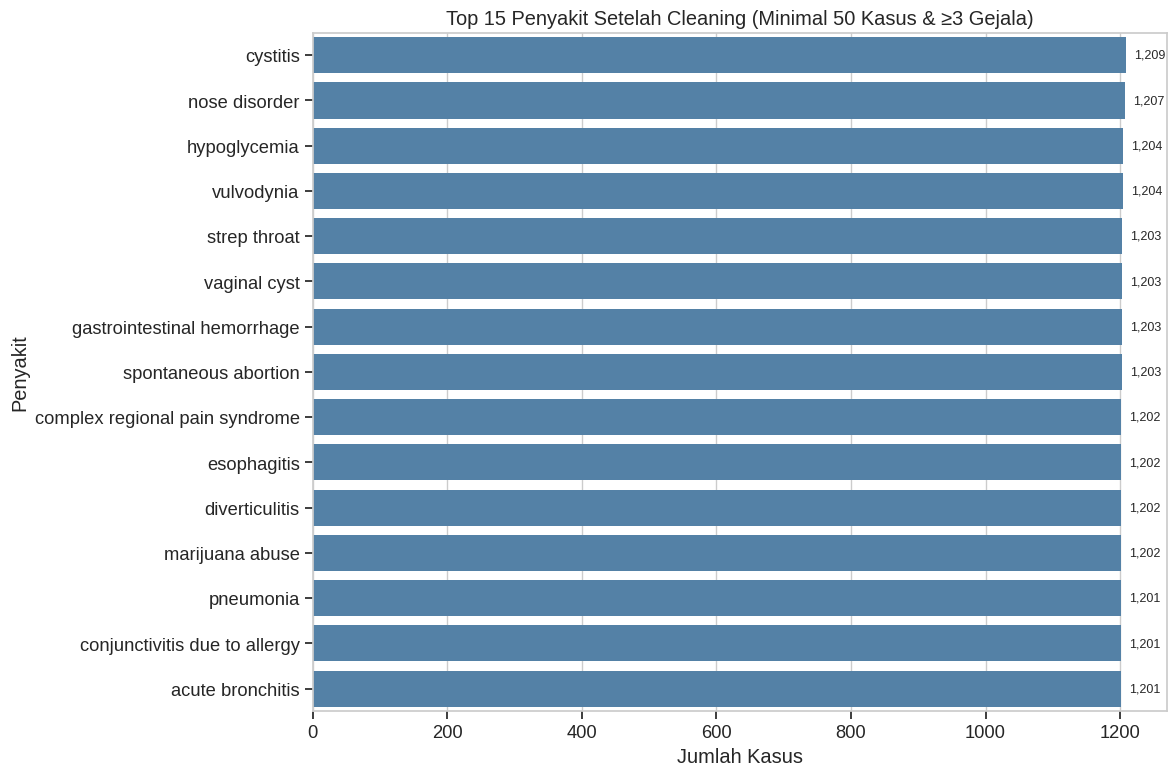

Total penyakit akhir: 413
Rata-rata kasus per penyakit: 437.1
Median kasus per penyakit: 298


In [ ]:
# Distribusi penyakit akhir - Top 15
final_disease_counts = df_clean_final['diseases'].value_counts()
top15_final = final_disease_counts.head(15)

plt.figure(figsize=(12, 8))

# Gunakan warna tunggal konsisten (steelblue) seperti visualisasi sebelumnya
ax = sns.barplot(x=top15_final.values, y=top15_final.index, color='steelblue')

# Tambahkan label angka di ujung setiap bar (meningkatkan integritas data)
for i, (nilai, nama) in enumerate(zip(top15_final.values, top15_final.index)):
    ax.text(nilai + (nilai * 0.01), i, f'{nilai:,}',
            va='center', ha='left', fontsize=9)

plt.xlabel('Jumlah Kasus')
plt.ylabel('Penyakit')
plt.title('Top 15 Penyakit Setelah Cleaning (Minimal 50 Kasus & ≥3 Gejala)')
plt.tight_layout()
plt.show()

print(f"Total penyakit akhir: {len(final_disease_counts)}")
print(f"Rata-rata kasus per penyakit: {final_disease_counts.mean():.1f}")
print(f"Median kasus per penyakit: {final_disease_counts.median():.0f}")

- **Penjelasan:** Dipetakan sebaran frekuensi kelas penyakit pasca-cleaning data melalui grafik batang horizontal untuk 15 penyakkit dengan jumlah sampel tertinggi. Untuk meningkatkan akurasi keterbacaan, iterasi 'for' diterapkan untuk mencantumkan label nilai numerik eksak secara presisi di setiap ujung batang grafik, yang ditutup dengan ringkasan statistik deskriptif berupa total penyakit unik, mean, dan median sampel.
- **Insight:**
  - Setelah melewati seleksi ketat (pembuangan penyakit <50 kasus dan rekam medis <3 gejala), dataset kini menyisakan 413 jenis penyakit unik dari total awal 773 kelas.
  - *Class imbalanced* ekstrem berhasil diredam, kini sebaran data jauh lebih padat dengan nilai rata-rata sampel per penyakit berada di angka 437,1 sampel dan nilai median stabil di angka 298 sampel.

### **Distribusi Jumlah Gejala per Baris (Final)**

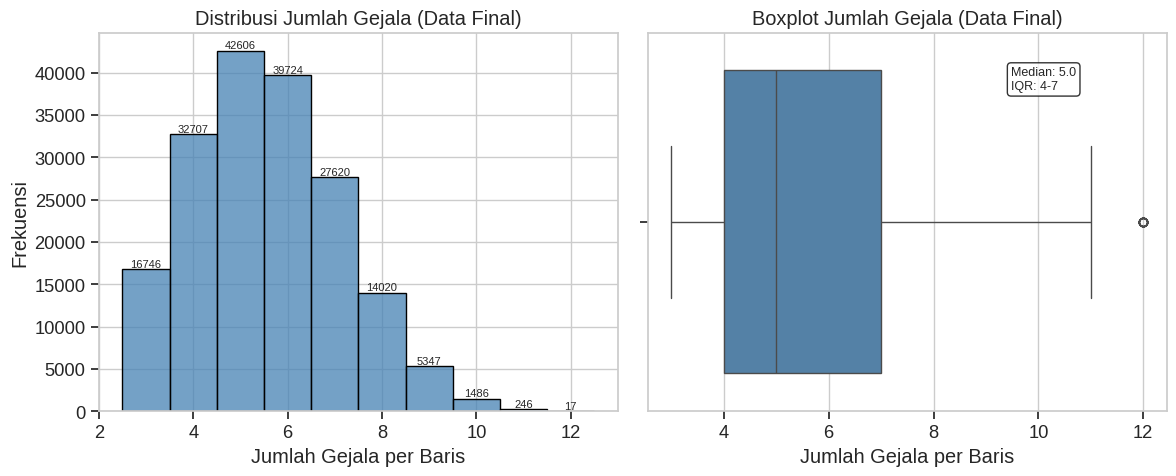

Statistik jumlah gejala per baris (Data Final):
count    180519.000000
mean          5.560816
std           1.581831
min           3.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          12.000000
dtype: float64


In [ ]:
# Distribusi jumlah gejala per baris (Data Final)
n_gejala_final = df_clean_final[gejala_columns].sum(axis=1)

plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
# Warna konsisten dengan visualisasi sebelumnya (steelblue), hapus edgecolor
sns.histplot(n_gejala_final, bins=12, discrete=True, color='steelblue')
plt.xlabel('Jumlah Gejala per Baris')
plt.ylabel('Frekuensi')
plt.title('Distribusi Jumlah Gejala (Data Final)')

# Tambahkan label nilai pada setiap batang (karena discrete)
counts = n_gejala_final.value_counts().sort_index()
for nilai, freq in counts.items():
    plt.text(nilai, freq + 10, str(freq), ha='center', va='bottom', fontsize=8)

# Subplot 2: Boxplot (warna konsisten)
plt.subplot(1, 2, 2)
sns.boxplot(x=n_gejala_final, color='steelblue')
plt.xlabel('Jumlah Gejala per Baris')
plt.title('Boxplot Jumlah Gejala (Data Final)')

# Tambahkan statistik ringkas pada plot (meningkatkan integritas data)
median_val = n_gejala_final.median()
q1_val = n_gejala_final.quantile(0.25)
q3_val = n_gejala_final.quantile(0.75)
plt.annotate(f'Median: {median_val}\nIQR: {q1_val:.0f}-{q3_val:.0f}',
             xy=(0.7, 0.85), xycoords='axes fraction', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Statistik jumlah gejala per baris (Data Final):")
print(n_gejala_final.describe())

- **Penjelasan:** Dilakukan evaluasi dan visualisasi struktur sebaran gejala per baris pada subset data hasil pembersihan final 'df_clean_final'. Dengan menjumlahkan nilai biner (1) di 377 kolom, mengonsturksi dua bentuk diagram, yaitu Histogram yang dilengkapi label freuensi otomatis di atas tiap batang serta Bxplot yang dilengkapi anotasi teks berisi median dan IQR. Juga mencetak rangkuman parameter statistik deskriptif.
- **Insight:**
  - Batas bawah yang sebelumnya berada di angka 1, kini telah bergeser dan terkunci di angka minimal 3 per baris, dengan max value tetap 12 gejala.
  - Mayoritas baris/sampel (IQR 4-7) gejala, berkumpul secara padat di sekitar nilai median 5 dan mean 5,56 gejala per baris.
  - Bentuk distribusi histogram menampilkan pola lonceng yang cenderung simetris, artinya kelompok <3 telah dibersihkan tanpa merusak bentuk alami sebaran data.

### **Jawaban Pertanyaan Bisnis**

In [ ]:
print("="*60)
print("JAWABAN PERTANYAAN BISNIS")
print("="*60)

print("\nQ1: Berapa banyak penyakit langka (<50 kasus) yang perlu dihapus?")
print(f"A1: {len(rare_diseases)} penyakit langka dihapus ({(len(rare_diseases)/773)*100:.1f}% dari total penyakit awal)")

print("\nQ2: Bagaimana distribusi jumlah gejala per penyakit?")
print(f"A2: Rata-rata gejala per baris = {n_gejala_final.mean():.2f}")
print(f"    Rentang gejala = {n_gejala_final.min()} - {n_gejala_final.max()} gejala")

print("\nQ3: Penyakit apa yang memiliki pola gejala paling unik?")
# Hitung penyakit dengan jumlah baris paling sedikit (paling langka setelah cleaning)
rarest_final = final_disease_counts.nsmallest(5)
print(f"A3: 5 penyakit dengan kasus paling sedikit (paling unik):")
for disease, count in rarest_final.items():
    print(f"    - {disease}: {count} kasus")

print("\nQ4: Gejala apa yang paling sering muncul?")
symptom_sum = df_clean_final[gejala_columns].sum().sort_values(ascending=False)
top5_symptoms = symptom_sum.head(5)
print(f"A4: 5 gejala paling umum:")
for symptom, count in top5_symptoms.items():
    print(f"    - {symptom}: muncul {count:,} kali ({count/len(df_clean_final)*100:.1f}% kasus)")

print("\nQ5: Setelah cleaning, berapa penyakit yang memiliki minimal 3 gejala?")
print(f"A5: {df_clean_final['diseases'].nunique()} penyakit (100% dari penyakit akhir)")

JAWABAN PERTANYAAN BISNIS

Q1: Berapa banyak penyakit langka (<50 kasus) yang perlu dihapus?
A1: 360 penyakit langka dihapus (46.6% dari total penyakit awal)

Q2: Bagaimana distribusi jumlah gejala per penyakit?
A2: Rata-rata gejala per baris = 5.56
    Rentang gejala = 3 - 12 gejala

Q3: Penyakit apa yang memiliki pola gejala paling unik?
A3: 5 penyakit dengan kasus paling sedikit (paling unik):
    - epilepsy: 47 kasus
    - myasthenia gravis: 50 kasus
    - dislocation of the elbow: 52 kasus
    - de quervain disease: 55 kasus
    - gynecomastia: 57 kasus

Q4: Gejala apa yang paling sering muncul?
A4: 5 gejala paling umum:
    - sharp abdominal pain: muncul 24,485 kali (13.6% kasus)
    - vomiting: muncul 21,642 kali (12.0% kasus)
    - nausea: muncul 18,500 kali (10.2% kasus)
    - cough: muncul 18,401 kali (10.2% kasus)
    - back pain: muncul 18,343 kali (10.2% kasus)

Q5: Setelah cleaning, berapa penyakit yang memiliki minimal 3 gejala?
A5: 413 penyakit (100% dari penyakit akhir

- **Penjelasan:** Tahap ini dilakukan untuk merangkum metrik operasional dan klinis utama pasca-cleaning data. Tahap ini menjawab 5 pertanyaan bisnis yang mencakup persentase pemangkasan data penyakit minor, statistik deskriptif distribusi gejala, identifikasi 5 penyakit dengan sampel paling terbatas '.nsmallest(5)', perhitungan kontribusi 5 gejala teratas, serta konfirmasi kepatuhan ambang batas minimum gejala.
- **Insight:**
  - Q1: Sebanyak 360 penyakit unik berhasil dieksklusi.
  - Q2: Setiap baris/sampel mengeluhkan 5,56 gejala, dengan rentang terdistribusi aman anatara 3-12 gejala.
  - Q3: Beberapa penyakit diidentifikasi sebagai kelas dengan profil data paling tipis setelah pembersihan, menjadi kelompok yang polanya paling sensitif.
  - Q4: Gejala *sharp abdominal pain* (muncul di 13,6% baris) dan *vomiting* (muncul 12% baris) diartikan sebagai dua indikator yang paling mendominasi dataset ini.
  - Q5: Sebanyak 413 penyakit unik divalidasi memiliki minimal 3 gejala.

### **Ringkasan Proses Data Wrangling**

In [ ]:
print("="*60)
print("RINGKASAN PROSES DATA WRANGLING")
print("="*60)

summary_data = {
    "Tahap": ["Dataset Awal", "Setelah Hapus Duplikat", "Setelah Hapus Penyakit Minor", "Setelah Penggabungan Gejala", "Dataset Final"],
    "Baris": [len(df_raw), len(df_clean), len(df_clean), len(df_clean), len(df_clean_final)],
    "Penyakit Unik": [df_raw['diseases'].nunique(), df_clean['diseases'].nunique(),
                      df_clean['diseases'].nunique(), df_clean['diseases'].nunique(),
                      df_clean_final['diseases'].nunique()]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\nTotal reduksi baris: {len(df_raw) - len(df_clean_final):,} baris ({(1 - len(df_clean_final)/len(df_raw))*100:.1f}%)")
print(f"Total reduksi penyakit: {df_raw['diseases'].nunique() - df_clean_final['diseases'].nunique()} penyakit")

RINGKASAN PROSES DATA WRANGLING
                       Tahap  Baris  Penyakit Unik
                Dataset Awal 246945            773
      Setelah Hapus Duplikat 184454            413
Setelah Hapus Penyakit Minor 184454            413
 Setelah Penggabungan Gejala 184454            413
               Dataset Final 180519            413

Total reduksi baris: 66,426 baris (26.9%)
Total reduksi penyakit: 360 penyakit


- **Penjelasan:** Dilakukan konsolidasi seluruh riwayat transformasi data dari awal smapai akhir. Melalui pemetaaan kamus Python 'summary_data' yang dikonversi menjadi 'pd.DataFrame', dilacak fluktasi jumlah baris dan variasi penyakit unik, lelau dihitung akumulasi total serta persentase reduksi data menggunakan operasi pengurangan dan pembagian.
- **Insight:**
  - Dataset akhir berhasil dikunci pada konfigurasi 180.519 baris dan 413 penyakit unik setelah mengeliminasi akumulasi bising sebanyak 66.426 baris (26,9% dari data awal) serta memangkas 360 jenis penyakit yang kekurangan sampel.
  - Dimensi tetap stabil setelah duplikat dihapus sampai penggabungan gejala di angka 184.454 baris, sebelum akhirnya menyusut ke angka final akibat penyaringan baris dibawah batas.

### **Validasi Akhir Dataset Final**

In [ ]:
print("="*50)
print("VALIDASI AKHIR DATASET FINAL")
print("="*50)

# Cek sebelum drop
duplicate_rows = df_clean_final.duplicated().sum()
print(f"Duplikat baris sebelum drop: {duplicate_rows}")

# Hapus duplikat jika masih ada
if duplicate_rows > 0:
    df_clean_final = df_clean_final.drop_duplicates()
    print(f" {duplicate_rows} duplikat dihapus")

# Validasi ulang
missing_total = df_clean_final.isnull().sum().sum()
duplicate_rows_after = df_clean_final.duplicated().sum()

print(f"\nDuplikat baris setelah drop: {duplicate_rows_after} (harus 0)")
print(f"Missing value: {missing_total} (harus 0)")
print(f"Total penyakit unik: {df_clean_final['diseases'].nunique()}")
print(f"Min sampel per penyakit: {df_clean_final['diseases'].value_counts().min()}")

assert duplicate_rows_after == 0, "Masih ada duplikat!"
assert missing_total == 0, "Masih ada missing value!"
print("\nDataset valid, siap diekspor")

VALIDASI AKHIR DATASET FINAL
Duplikat baris sebelum drop: 304
 304 duplikat dihapus

Duplikat baris setelah drop: 0 (harus 0)
Missing value: 0 (harus 0)
Total penyakit unik: 413
Min sampel per penyakit: 46

Dataset valid, siap diekspor


- **Penjelasan:** Tahap audit integritas dataset sebelum diekspor ke format .csv, dengan mendeteksi keberadaan baris duplikay tersembunyi dan missing values. Jika ditemukan duplikay, blok 'if' akan mengeksekusi untuk memberishkan secara otomatis.
- **Insight:**
  - Hasil evaluasi mendeteksi adanya 304 baris duplikat baru yang muncul akibat proses penggabungan baris (OR logic) pada fase penyelamatan data sebelumnya.
  - Berhasil mendeteksi dan menghapus ke-304 duplikat tersebut hingga mencapai angka 0 duplikat dan 0 missing values.

### **Ekspor Dataset Bersih**

In [ ]:
print("="*60)
print("EKSPOR DATASET FINAL")
print("="*60)

# Simpan langsung di root Colab (/content/)
csv_path = '/content/diagnoku_biner_v5.csv'
df_clean_final.to_csv(csv_path, index=False)

print(f"Dataset bersih disimpan di: {csv_path}")
print(f"   Shape: {df_clean_final.shape}")
print(f"   Total baris: {len(df_clean_final):,}")
print(f"   Total kolom: {len(df_clean_final.columns)} (1 penyakit + {len(df_clean_final.columns)-1} gejala)")
print(f"   Total penyakit unik: {df_clean_final['diseases'].nunique()}")
print(f"   Memory: {df_clean_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

EKSPOR DATASET FINAL
Dataset bersih disimpan di: /content/diagnoku_biner_v5.csv
   Shape: (180215, 378)
   Total baris: 180,215
   Total kolom: 378 (1 penyakit + 377 gejala)
   Total penyakit unik: 413
   Memory: 77.58 MB


- **Penjelasan:** Dataset final yang ebrsih dieskpor dengan format '.csv' dengan nama 'diagnoku_biner_v5/csv'. Lalau dicetak laporan ringkas yang mencakup lokasi penyimpanan, *shape*, pembagian jenis kolom, jumlah target penyakit nik, dan akumulasi penggunaan memori RAM.
- **Insight:**
  - File CSV berdimensi akhir sebesar 180.215 baris dan 378 kolom (1 kolom target, 377 fitur gejala biner).
  - Optimasi tipe data ke format bit terendah konsisten sejak awal fase, hanya mengonsumsi memosri sebesar 77,58 MB.

## **Fase 4: Pembuatan Kamus Sinonim Gejala**

### **Load Dataset Bersih**

In [ ]:
df_v5 = pd.read_csv('/content/drive/MyDrive/DS_CC26-PSU200/Clean Dataset/diagnoku_biner_v5.csv')
# Optimasi tipe data int8 untuk efisiensi memori (Data Biner)
cols_biner = df_v5.columns.drop('diseases')
df_v5[cols_biner] = df_v5[cols_biner].apply(pd.to_numeric, downcast='integer')

print(f"\nDataset Biner V5 : {df_v5.shape} | Memory: {df_v5.memory_usage().sum()/1024**2:.2f} MB")
display(df_v5.head())


Dataset Biner V5 : (180215, 378) | Memory: 66.17 MB


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling h

- **Penjelasan:** Dilakukan pemuatan kembali file dataset biner versi bersih 'diagnoku_biner_v5.csv' dari google drive. Dataset bersih ini langsung diterapkan *memory downcasting* untuk ubah tipe bawaan numerik standar menjadi tipe integer terkecil 'int8'.


### **Tampilkan Daftar Seluruh Gejala**

In [ ]:
# Mengurutkan nama gejala
daftar_gejala = sorted(cols_biner)

print(f"Daftar Lengkap Gejala ({len(daftar_gejala)} gejala):\n")
for i, gejala in enumerate(daftar_gejala, 1):
    print(f"{i}. {gejala}")

Daftar Lengkap Gejala (377 gejala):

1. abdominal distention
2. abnormal appearing skin
3. abnormal appearing tongue
4. abnormal breathing sounds
5. abnormal involuntary movements
6. abnormal movement of eyelid
7. abnormal size or shape of ear
8. absence of menstruation
9. abusing alcohol
10. ache all over
11. acne or pimples
12. allergic reaction
13. ankle pain
14. ankle stiffness or tightness
15. ankle swelling
16. ankle weakness
17. antisocial behavior
18. anxiety and nervousness
19. apnea
20. arm cramps or spasms
21. arm lump or mass
22. arm pain
23. arm stiffness or tightness
24. arm swelling
25. arm weakness
26. back cramps or spasms
27. back mass or lump
28. back pain
29. back stiffness or tightness
30. back swelling
31. back weakness
32. bedwetting
33. bladder mass
34. bleeding from ear
35. bleeding from eye
36. bleeding gums
37. bleeding in mouth
38. bleeding or discharge from nipple
39. blindness
40. blood clots during menstrual periods
41. blood in stool
42. blood in urine
4

- **Penjelasan:** Tahap ini untuk mengekstrak, mengurutkan, dan mengaudit seluruh dimensi fitur gejala yang terdaftar dalam dataset bersih. Digunakan untuk mengetahui nama gejala untuk kebutuhan mapping manual di tahap selanjutnya.
- **Insight:** Outputnya dipetakan secara gamblang daftar lengkap 377 gejala unik.

### **Mapping Manual Sinonim Gejala**

In [ ]:
kamus_sinonim_gejala_diagnokuV5 = {
    "abdominal distention": [
        "perut distensi", "penumpukan gas di perut", "penumpukan cairan di perut",
        "perut kembung", "perut begah", "perut membesar", "perut buncit mendadak",
        "begah", "kembung", "bloating", "perut penuh", "sebah"
    ],
    "abnormal appearing skin": [
        "kelainan tampilan kulit", "lesi kulit", "kulit kelihatan aneh",
        "kulit berubah warna", "ada bercak bercak di kulit", "kulit bruntusan",
        "kulit kelainan", "kulit burik", "budukan", "korengan", "bentol bentol",
        "bercak aneh"
    ],
    "abnormal appearing tongue": [
        "kelainan tampilan lidah", "lidah kelihatan aneh", "lidah putih putih",
        "lidah pecah pecah", "lidah sariawan parah", "lidah mati rasa",
        "lidah jamuran", "lidah sariawan", "lidah baal"
    ],
    "abnormal breathing sounds": [
        "suara napas abnormal", "suara napas tambahan", "stridor", "wheezing", "ronkhi",
        "napas bunyi", "napas berbunyi ngik ngik", "napas grook grook", "napas sesak bunyi",
        "napas bengek", "mengorok", "napas bunyi ayam", "wheezing"
    ],
    "abnormal involuntary movements": [
        "gerakan tidak terkendali", "gerakan involunter", "gerakan tubuh aneh sendiri",
        "anggota tubuh gerak gerak sendiri", "sering kagetan", "kejang halus",
        "kedutan parah", "tremor", "gemetaran", "twitching", "gerakan refleks aneh"
    ],
    "abnormal movement of eyelid": [
        "gerakan kelopak mata abnormal", "kelopak mata kedutan terus",
        "mata berkedip kedip sendiri", "mata merem melek sendiri",
        "kedutan mata", "mata tic", "mata kedut kedut"
    ],
    "abnormal size or shape of ear": [
        "kelainan bentuk telinga", "kelainan ukuran telinga", "malformasi telinga",
        "telinga bentuknya aneh", "daun telinga besar sebelah", "telinga kecil sebelah",
        "kuping caplang", "kuping ciut", "kuping aneh"
    ],
    "absence of menstruation": [
        "amenore", "tidak adanya menstruasi", "tidak datang bulan", "belum haid",
        "telat menstruasi berbulan bulan", "menstruasi stop", "telat dapet",
        "nggak dapet menses", "telat bulan"
    ],
    "abusing alcohol": [
        "penyalahgunaan alkohol", "alkoholisme", "pecandu alkohol", "suka mabuk mabukan",
        "ketergantungan minuman keras", "miras", "pemabuk", "hobi mendem",
        "hobi mabok", "peminum berat", "alko", "alkoholik"
    ],
    "ache all over": [
        "mialgia generalisata", "nyeri seluruh tubuh", "badan sakit semua",
        "seluruh badan linu", "badan pegal pegal sebadan", "badan rasanya remuk",
        "badan jompo", "badan remuk", "pegal linu", "ringsek", "meriang"
    ],
    "acne or pimples": [
        "akne vulgaris", "jerawatan", "muka beruntusan", "banyak bisul kecil di muka",
        "bruntusan", "muka panen", "breakout"
    ],
    "allergic reaction": [
        "reaksi alergi", "hipersensitivitas", "alergi kambuh",
        "gatal gatal karena makanan", "gatal gatal karena debu", "biduran",
        "bersin bersin karena alergi", "kaligata", "bentol alergi"
    ],
    "ankle pain": [
        "nyeri pergelangan kaki", "pergelangan kaki sakit", "mata kaki nyeri",
        "sakit buat jalan", "engkel sakit", "engkel nyeri", "salah urat kaki"
    ],
    "ankle stiffness or tightness": [
        "kaku pada pergelangan kaki", "pergelangan kaki kaku",
        "engkel kaku susah digerakkan", "mata kaki tegang", "engkel kaku",
        "engkel stiff", "kaki kaku"
    ],
    "ankle swelling": [
        "edema pergelangan kaki", "pergelangan kaki bengkak", "mata kaki bengkak",
        "engkel bengkak", "kaki gajah", "kaki bengkak"
    ],
    "ankle weakness": [
        "kelemahan pada pergelangan kaki", "pergelangan kaki lemas", "engkel letoy",
        "kaki sering tertekuk sendiri saat jalan", "kaki lemas", "engkel lemah"
    ],
    "antisocial behavior": [
        "perilaku antisosial", "gangguan kepribadian antisosial", "menolak bergaul",
        "tidak mau bersosialisasi", "suka menyendiri", "menjauhi orang orang",
        "ansos", "kuper", "kurang pergaulan", "introvert parah", "anti sosial"
    ],
    "anxiety and nervousness": [
        "ansietas", "kecemasan", "kegugupan", "merasa cemas", "gugup", "gelisah",
        "khawatir berlebihan", "deg degan terus", "overthinking", "panikan",
        "anxious", "ketar ketir", "jantungan", "nervous"
    ],
    "apnea": [
        "apnea", "henti napas sementara", "napas sempat berhenti pas tidur",
        "tiba tiba megap megap pas tidur", "seperti tercekik saat tidur",
        "sleep apnea", "megap megap", "seperti ketindihan"
    ],
    "arm cramps or spasms": [
        "spasme otot lengan", "kram lengan", "tangan kram", "lengan kaku mendadak",
        "otot lengan ketarik", "otot lengan kejang", "lengan kaku", "otot ketarik"
    ],
    "arm lump or mass": [
        "massa lengan", "benjolan lengan", "benjolan di tangan", "ada daging tumbuh di lengan",
        "tangan benjol", "lengan bengkak berbenjol", "ucleng", "benjolan tangan"
    ],
    "arm pain": [
        "nyeri lengan", "sakit lengan", "tangan sakit", "lengan linu",
        "tangan nyeri", "sakit tangan", "tangan pegal"
    ],
    "arm stiffness or tightness": [
        "kaku pada lengan", "lengan kaku", "tangan tegang", "lengan kencang",
        "tangan kaku susah digerakkan", "tangan stiff", "lengan kaku"
    ],
    "arm swelling": [
        "edema lengan", "lengan bengkak", "tangan bengkak", "lengan membesar",
        "tangan bengkak", "tangan gede sebelah"
    ],
    "arm weakness": [
        "kelemahan lengan", "lengan lemas", "tangan lemas", "tangan letoy",
        "tangan tidak bertenaga", "lengan lemah", "tangan lunglai", "tangan ga bisa ngangkat"
    ],
    "back cramps or spasms": [
        "spasme otot punggung", "kram punggung", "punggung kejang", "otot punggung ketarik",
        "punggung kram", "boyok kram", "pinggang ketarik"
    ],
    "back mass or lump": [
        "massa punggung", "benjolan punggung", "benjolan di pinggang", "ucleng di punggung",
        "punggung benjol", "ada daging tumbuh di punggung"
    ],
    "back pain": [
        "nyeri punggung", "sakit punggung", "sakit pinggang", "nyeri pinggang",
        "boyokan", "sakit boyok", "encok", "punggung pegal", "sakit tulang belakang"
    ],
    "back stiffness or tightness": [
        "kaku pada punggung", "punggung kaku", "pinggang kaku", "punggung tegang",
        "boyok kaku", "punggung stiff", "pinggang tegang"
    ],
    "back swelling": [
        "edema punggung", "punggung bengkak", "pinggang bengkak", "bengkak di punggung"
    ],
    "back weakness": [
        "kelemahan punggung", "punggung lemas", "pinggang lemas", "boyok letoy",
        "punggung tidak bertenaga", "tidak kuat tegak", "punggung lemah"
    ],
    "bedwetting": [
        "enuresis", "mengompol", "ngompol", "kencing di kasur",
        "ngompol pas tidur", "pipis di celana pas tidur"
    ],
    "bladder mass": [
        "massa kandung kemih", "benjolan kandung kemih", "tumor kandung kemih",
        "ada benjolan di tempat pipis", "massa di kantung kemih"
    ],
    "bleeding from ear": [
        "perdarahan telinga", "telinga berdarah", "keluar darah dari kuping",
        "kuping berdarah", "darah keluar dari telinga"
    ],
    "bleeding from eye": [
        "perdarahan mata", "mata berdarah", "keluar darah dari mata",
        "mata keluar darah", "perdarahan konjungtiva"
    ],
    "bleeding gums": [
        "perdarahan gusi", "gusi berdarah", "gusi sering berdarah",
        "gusi berdarah pas sikat gigi"
    ],
    "bleeding in mouth": [
        "perdarahan mulut", "mulut berdarah", "keluar darah dari mulut",
        "mulut keluar darah", "darah di dalam mulut"
    ],
    "bleeding or discharge from nipple": [
        "perdarahan puting", "puting keluar cairan", "puting keluar darah",
        "puting susu berdarah", "keluar cairan aneh dari puting", "discharge puting"
    ],
    "blindness": [
        "kebutaan", "buta", "tidak bisa melihat", "kehilangan penglihatan",
        "mata buta", "gelap total"
    ],
    "blood clots during menstrual periods": [
        "gumpalan darah menstruasi", "darah haid menggumpal", "haid keluar darah beku",
        "darah haid seperti ati ayam", "menstruasi menggumpal", "darah kental pas haid"
    ],
    "blood in stool": [
        "darah dalam tinja", "buang air besar berdarah", "bab berdarah",
        "feses berdarah", "bab keluar darah", "berak berdarah", "feses ada darahnya"
    ],
    "blood in urine": [
        "hematuria", "darah dalam urine", "kencing berdarah", "pipis berdarah",
        "urine berdarah", "air kencing warna merah darah"
    ],
    "bones are painful": [
        "nyeri tulang", "tulang sakit", "tulang linu", "sakit di dalam tulang",
        "tulang rasanya ngilu", "tulang linu linu"
    ],
    "bowlegged or knock-kneed": [
        "kaki o", "kaki x", "genu varum", "genu valgum", "kaki bengkok",
        "tulang kaki melengkung", "kaki pengkor"
    ],
    "breathing fast": [
        "takipnea", "napas cepat", "bernapas cepat", "napas terengah engah",
        "napas memburu", "ngos ngosan", "napas buru buru"
    ],
    "bumps on penis": [
        "bintik di penis", "benjolan di penis", "kutil kelamin", "penis beruntusan",
        "ada kutil di kemaluan pria", "bintik bintik di alat kelamin"
    ],
    "burning abdominal pain": [
        "nyeri perut membakar", "perut terasa terbakar", "perut perih panas",
        "sakit ulu hati panas", "lambung perih terbakar", "perut panas"
    ],
    "burning chest pain": [
        "nyeri dada membakar", "dada terasa terbakar", "dada panas",
        "nyeri dada panas", "heartburn", "dada rasanya terbakar"
    ],
    "change in skin mole size or color": [
        "perubahan tahi lalat", "tahi lalat membesar", "tahi lalat berubah warna",
        "tahi lalat gatal dan membesar", "tahi lalat aneh"
    ],
    "changes in stool appearance": [
        "perubahan bentuk tinja", "feses berubah warna", "bentuk bab aneh",
        "feses mengecil seperti kotoran kambing", "warna bab tidak normal"
    ],
    "chest tightness": [
        "dada tertekan", "dada terasa sempit", "dada sesak", "dada terasa berat",
        "dada seperti dihimpit", "dada ampek", "dada nyesek"
    ],
    "chills": [
        "menggigil", "kedinginan", "merinding kedinginan", "badan menggigil",
        "gemetar karena dingin"
    ],
    "cloudy eye": [
        "mata keruh", "mata berkabut", "lensa mata putih", "mata katarak",
        "penglihatan berawan", "mata mripat keruh"
    ],
    "congestion in chest": [
        "kongesti dada", "dada penuh lendir", "dada sesak berdahak",
        "paru paru penuh dahak", "dada terasa mampet"
    ],
    "constipation": [
        "konstipasi", "sembelit", "susah buang air besar", "susah bab",
        "bebelen", "bab keras", "kurang lancar bab"
    ],
    "coryza": [
        "koriza", "pilek", "flu", "hidung meler", "ingusan",
        "hidung tersumbat", "selesma"
    ],
    "cough": [
        "batuk", "batuk batuk", "sering batuk", "gatal tenggorokan batuk"
    ],
    "coughing up sputum": [
        "batuk berdahak", "batuk keluar lendir", "batuk ada dahaknya",
        "batuk mbecek"
    ],
    "cramps and spasms": [
        "kram", "spasme", "kejang otot", "otot kaku mendadak",
        "kedutan kejang", "kram kram"
    ],
    "cross-eyed": [
        "strabismus", "mata juling", "juling", "mata tidak sejajar",
        "pandangan juling"
    ],
    "decreased appetite": [
        "anoreksia", "penurunan nafsu makan", "tidak nafsu makan", "kurang nafsu makan",
        "gajelas mau makan apa", "ga doyan makan", "malas makan", "hilang nafsu makan"
    ],
    "decreased heart rate": [
        "bradikardia", "denyut jantung lambat", "detak jantung melemah",
        "jantung berdetak pelan", "detak jantung rendah", "nadi lambat"
    ],
    "delusions or hallucinations": [
        "delusi", "halusinasi", "waham", "halu", "melihat hal gaib",
        "mendengar bisikan", "berpikiran aneh", "salah anggapan", "paranoia parah"
    ],
    "depression": [
        "depresi", "gangguan depresi", "stres berat", "depresif",
        "sedih berkepanjangan", "putus asa", "kesehatan mental terganggu"
    ],
    "depressive or psychotic symptoms": [
        "gejala depresif", "gejala psikotik", "gejala gila", "gangguan mental parah",
        "sering melamun sedih", "bicara sendiri", "kehilangan kontak realitas"
    ],
    "diaper rash": [
        "ruam popok", "dermatitis popok", "kulit bayi kemerahan",
        "pantat bayi lecet popok", "ruam susu", "biang keringat popok"
    ],
    "diarrhea": [
        "diare", "mencret", "buang air besar cair", "bab terus menerus",
        "menceret", "mencret mencret", "urus urus", "sakit perut bab cair"
    ],
    "difficulty breathing": [
        "dispnea", "kesulitan bernapas", "sesak napas", "susah napas",
        "napas berat", "engap", "megap megap", "napas pendek"
    ],
    "difficulty eating": [
        "kesulitan makan", "susah makan", "tidak bisa masuk makanan",
        "muntah tiap makan", "gagal makan"
    ],
    "difficulty in swallowing": [
        "disfagia", "kesulitan menelan", "susah menelan", "sakit pas menelan",
        "tenggorokan ganjel pas makan", "nyeri menelan"
    ],
    "difficulty speaking": [
        "disartria", "kesulitan berbicara", "susah ngomong", "bicara tidak jelas",
        "gagu mendadak", "pelo", "ngomong rariut", "bicara berat"
    ],
    "diminished hearing": [
        "penurunan pendengaran", "pendengaran berkurang", "tuli sebagian",
        "kurang dengar", "telinga budeg mendadak", "kuping pengang", "budek"
    ],
    "diminished vision": [
        "penurunan penglihatan", "penglihatan berkurang", "mata kabur",
        "pandangan buram", "mata blawur", "pandangan tidak jelas", "rabun"
    ],
    "discharge in stools": [
        "lendir dalam tinja", "bab berlendir", "feses ada lendirnya",
        "tinja keluar lendir", "berak lendir"
    ],
    "disturbance of memory": [
        "gangguan memori", "gangguan ingatan", "sering lupa", "pikun",
        "mudah lupa", "linglung", "kehilangan ingatan short term"
    ],
    "disturbance of smell or taste": [
        "anosmia", "ageusia", "gangguan penciuman", "gangguan indra perasa",
        "mati rasa lidah", "tidak bisa mencium bau", "hambar", "ga rasain makanan"
    ],
    "dizziness": [
        "pusing", "puyeng", "keliyengan", "vertigo", "kepala muter",
        "sakit kepala berputar", "kliyengan", "kepala kliyengan"
    ],
    "double vision": [
        "diplopia", "penglihatan ganda", "melihat bayangan kembar",
        "pandangan berbayang", "melihat satu jadi dua"
    ],
    "drainage in throat": [
        "post nasal drip", "lendir di tenggorokan", "dahak mengalir di tenggorokan",
        "tenggorokan gatal berlendir", "seperti ada riak tertahan"
    ],
    "drug abuse": [
        "penyalahgunaan obat", "penyalahgunaan narkoba", "pecandu narkoba",
        "sakaw", "ketergantungan obat terlarang", "pemakai obat", "penyalahgunaan zat"
    ],
    "dry lips": [
        "bibir kering", "bibir pecah pecah", "bibir mengelupas",
        "bibir garing", "bibir pecah"
    ],
    "dry or flaky scalp": [
        "kulit kepala kering", "kulit kepala mengelupas", "ketombean parah",
        "ketombe", "kulit kepala bersisik"
    ],
    "ear pain": [
        "otalgia", "nyeri telinga", "sakit telinga", "kuping sakit",
        "telinga nyut nyutan", "sakit kuping"
    ],
    "early or late onset of menopause": [
        "menopause dini", "menopause terlambat", "telat menopause",
        "menopause kecepetan", "berhenti haid awal"
    ],
    "elbow cramps or spasms": [
        "spasme sikut", "kram siku", "siku kram mendadak", "otot sikut kejang",
        "siku kaku ketarik"
    ],
    "elbow lump or mass": [
        "massa siku", "benjolan di siku", "siku benjol", "ucleng di sikut",
        "ada daging tumbuh di siku"
    ],
    "elbow pain": [
        "nyeri siku", "sakit siku", "siku sakit", "sikut linu",
        "nyeri sikut"
    ],
    "elbow stiffness or tightness": [
        "kaku pada siku", "siku kaku", "sikut tegang", "siku kencang susah ditekuk",
        "sikut stiff"
    ],
    "elbow swelling": [
        "edema siku", "siku bengkak", "sikut bengkak", "bengkak di siku"
    ],
    "elbow weakness": [
        "kelemahan siku", "siku lemas", "sikut letoy", "siku tidak bertenaga",
        "sikut lemah untuk ngangkat"
    ],
    "emotional symptoms": [
        "gejala emosional", "suasana hati tidak stabil", "emosi tidak stabil",
        "mood swings", "gampang nangis", "sensitif parah", "baperan"
    ],
    "excessive anger": [
        "marah berlebihan", "mudah marah", "gampang ngamuk", "temperamental",
        "darah tinggi", "gampang emosi", "senggol bacok"
    ],
    "excessive appetite": [
        "hiperfagia", "nafsu makan berlebihan", "maruk makan", "gila makan",
        "laperan terus", "bawaannya pengen makan", "makan banyak banget"
    ],
    "excessive growth": [
        "gigantisme", "pertumbuhan berlebihan", "tumbuh terlalu cepat",
        "badan bongsor mendadak", "terlalu tinggi"
    ],
    "excessive urination at night": [
        "nokturia", "sering kencing malam hari", "sering pipis pas tidur",
        "pipis bolak balik tiap malam", "kebangun malam buat pipis"
    ],
    "eye burns or stings": [
        "mata terasa membakar", "mata perih", "mata panas", "mata kayak kena sabun",
        "mata nyes perih", "mata sepet perih"
    ],
    "eye deviation": [
        "deviasi mata", "mata juling", "arah mata melenceng", "posisi mata tidak simetris"
    ],
    "eye moves abnormally": [
        "nistagmus", "gerakan mata abnormal", "mata bergerak sendiri",
        "bola mata kedut kedut", "mata lari lari sendiri"
    ],
    "eye redness": [
        "mata merah", "mata memerah", "konjungtivitas", "mata iritasi merah",
        "mripat abang", "mata belekan merah"
    ],
    "eye strain": [
        "asthenopia", "mata lelah", "mata tegang", "mata capek",
        "mata sepet", "lelah karena layar"
    ],
    "eyelid lesion or rash": [
        "lesi kelopak mata", "ruam kelopak mata", "bintitan", "kelopak mata bintilan",
        "ada benjolan kecil di kelopak mata", "kelopak mata bruntusan", "kalazion"
    ],
    "eyelid retracted": [
        "retraksi kelopak mata", "kelopak mata tertarik ke atas", "mata melotot",
        "kelopak mata tidak bisa menutup sempurna", "mata mencorong"
    ],
    "eyelid swelling": [
        "edema kelopak mata", "kelopak mata bengkak", "mata bengkak",
        "kelopak mata sembab", "mata sembap"
    ],
    "facial pain": [
        "nyeri wajah", "sakit wajah", "muka sakit", "sakit di area muka",
        "nyeri rahang dan wajah", "muka linu"
    ],
    "fainting": [
        "sinkop", "pingsan", "hilang kesadaran", "tidak sadarkan diri",
        "ambruk", "pingsan mendadak", "teler pasrah"
    ],
    "fatigue": [
        "kelelahan", "lelah", "letih", "lesu", "lemas", "gampang capek",
        "kurang energi", "fatik", "badan jompo", "loyo", "lowbat"
    ],
    "fears and phobias": [
        "ketakutan", "fobia", "takut berlebihan", "trauma", "paranoid",
        "ciut", "parno", "pobia"
    ],
    "feeling cold": [
        "merasa dingin", "kedinginan", "merasa menggigil", "badan adem",
        "sensitif dingin"
    ],
    "feeling hot": [
        "merasa panas", "kepanasan", "gerah", "badan terasa hangat",
        "sumeng", "hot flashes"
    ],
    "feeling hot and cold": [
        "merasa panas dingin", "meriang", "badan tidak menentu", "panas dingin",
        "demam meriang", "greges greges"
    ],
    "feeling ill": [
        "merasa sakit", "tidak enak badan", "kurang sehat", "merasa sakit",
        "drop", "kurang fit", "mau sakit"
    ],
    "feet turned in": [
        "kaki pengkor ke dalam", "kaki jinjit ke dalam", "metatarsus varus",
        "telapak kaki menghadap ke dalam", "kaki letter x"
    ],
    "fever": [
        "demam", "panas badan", "badan panas", "suhu tubuh tinggi",
        "sumeng", "meriang panas"
    ],
    "flatulence": [
        "flatulensi", "sering kentut", "buang angin terus", "gassy",
        "banyak gas di perut", "kentut kentut"
    ],
    "flu-like syndrome": [
        "sindrom mirip flu", "gejala flu", "gejala masuk angin", "meriang batuk pilek",
        "badan pegal linu flu"
    ],
    "fluid in ear": [
        "cairan di telinga", "telinga berair", "kuping berair", "keluar cairan dari kuping",
        "telinga meler", "congean"
    ],
    "fluid retention": [
        "retensi cairan", "penumpukan cairan", "tubuh bengkak air", "edema",
        "badan membengkak"
    ],
    "flushing": [
        "wajah memerah", "muka merah merona", "kulit memerah mendadak",
        "muka kepanasan merah", "blushing"
    ],
    "focal weakness": [
        "kelemahan fokal", "lemas sebagian tubuh", "lemas sebelah",
        "tangan atau kaki lemas sesisi", "gejala stroke ringan", "lemas terlokalisir"
    ],
    "foot or toe cramps or spasms": [
        "kram kaki", "kram jari kaki", "kaki kram mendadak", "jempol kaki kaku ketarik",
        "kejang otot kaki"
    ],
    "foot or toe lump or mass": [
        "massa kaki", "benjolan di kaki", "benjolan jari kaki", "mata ikan",
        "ucleng di kaki", "ada daging tumbuh di telapak kaki"
    ],
    "foot or toe pain": [
        "nyeri kaki", "sakit kaki", "nyeri jari kaki", "telapak kaki sakit",
        "jempol kaki senut senut", "kaki linu"
    ],
    "foot or toe stiffness or tightness": [
        "kaku pada kaki", "kaki kaku", "jari kaki kaku", "telapak kaki tegang",
        "kaki stiff"
    ],
    "foot or toe swelling": [
        "edema kaki", "kaki bengkak", "jari kaki bengkak", "telapak kaki membengkak"
    ],
    "foot or toe weakness": [
        "kelemahan kaki", "kaki lemas", "jari kaki letoy", "kaki lumpuh sebagian",
        "kaki tidak bertenaga untuk jalan"
    ],
    "foreign body sensation in eye": [
        "sensasi benda asing di mata", "mata terasa diganjal", "mata kelilipan",
        "seperti ada pasir di mata", "mata ganjel", "kelilipan"
    ],
    "frequent menstruation": [
        "polimenore", "menstruasi sering", "haid terlalu sering", "jarak haid dekat",
        "sebulan bisa dua kali haid", "haid berulang kali"
    ],
    "frequent urination": [
        "sering buang air kecil", "sering kencing", "sering pipis", "beser",
        "pipis bolak balik", "kencing terus menerus", "anyang anyangan"
    ],
    "frontal headache": [
        "sakit kepala frontal", "sakit kepala bagian depan", "sakit kepala di jidat",
        "pusing bagian depan", "jidat senut senut"
    ],
    "groin mass": [
        "massa selangkangan", "benjolan di selangkangan", "turun berok",
        "hernia selangkangan", "selangkangan benjol"
    ],
    "groin pain": [
        "nyeri selangkangan", "sakit selangkangan", "selangkangan linu",
        "nyeri lipatan paha", "selangkangan sakit buat jalan"
    ],
    "gum pain": [
        "nyeri gusi", "gusi sakit", "gusi linu", "gusi bengkak sakit",
        "gusi senut senut"
    ],
    "hand or finger cramps or spasms": [
        "kram tangan", "kram jari tangan", "tangan kaku mendadak",
        "jari tangan kaku ketarik", "kejang otot tangan"
    ],
    "hand or finger lump or mass": [
        "massa tangan", "benjolan di tangan", "benjolan jari tangan",
        "ganglion", "ucleng di tangan", "tangan benjol"
    ],
    "hand or finger pain": [
        "nyeri tangan", "sakit tangan", "nyeri jari tangan",
        "jari tangan senut senut", "tangan linu"
    ],
    "hand or finger stiffness or tightness": [
        "kaku pada tangan", "tangan kaku", "jari tangan kaku",
        "tangan stiff susah ditekuk", "jari tangan kaku pagi hari"
    ],
    "hand or finger swelling": [
        "edema tangan", "tangan bengkak", "jari tangan bengkak",
        "tangan membengkak"
    ],
    "hand or finger weakness": [
        "kelemahan tangan", "tangan lemas", "jari tangan letoy",
        "tangan tidak bertenaga", "tidak kuat memegang", "tangan drop"
    ],
    "headache": [
        "sakit kepala", "pusing", "kepala pusing", "kepala berat",
        "migraine", "puyeng", "pusing nyut nyutan"
    ],
    "heartburn": [
        "heartburn", "sensasi terbakar di dada", "ulu hati panas",
        "asam lambung naik", "dada panas karena lambung", "perih ulu hati"
    ],
    "heavy menstrual flow": [
        "menoragia", "menstruasi berat", "darah haid banyak", "haid banjir",
        "ganti pembalut berkali kali", "darah haid keluar banyak banget"
    ],
    "hemoptysis": [
        "hemoptisis", "batuk berdarah", "batuk keluar darah", "muntah darah saat batuk"
    ],
    "hesitancy": [
        "hesitansi urine", "susah memulai kencing", "pipis tersendat",
        "pipis harus mengejan", "kencing tidak lancar keluar", "pipis mampet awal"
    ],
    "hip lump or mass": [
        "massa pinggul", "benjolan di pinggul", "pinggul benjol",
        "ada daging tumbuh di pinggul"
    ],
    "hip pain": [
        "nyeri pinggul", "sakit pinggul", "pinggul linu", "panggul sakit"
    ],
    "hip stiffness or tightness": [
        "kaku pada pinggul", "pinggul kaku", "panggul kaku susah digerakkan",
        "pinggul tegang", "pinggul stiff"
    ],
    "hip swelling": [
        "edema pinggul", "pinggul bengkak", "panggul membengkak"
    ],
    "hip weakness": [
        "kelemahan pinggul", "pinggul lemas", "pinggul letoy",
        "pinggul tidak kuat menopang", "panggul lemas"
    ],
    "hoarse voice": [
        "suara serak", "serak", "suara hilang", "suara parau", "suara habis"
    ],
    "hostile behavior": [
        "perilaku bermusuhan", "agresif", "suka menantang", "mudah menyerang",
        "gampang ngajak berantem", "galak", "suka cari ribut"
    ],
    "hot flashes": [
        "hot flashes", "sensasi panas mendadak", "tubuh rasa kepanasan tiba tiba",
        "semburan panas", "gerah mendadak karena menopause"
    ],
    "hurts to breath": [
        "nyeri saat bernapas", "sakit pas napas", "napas terasa sakit",
        "dada nyeri kalau napas", "napas nyesek sakit", "dada linu pas narik napas"
    ],
    "hysterical behavior": [
        "perilaku histeris", "histeris", "teriak histeris", "mengamuk tidak terkontrol",
        "tantrum parah", "reaksi emosional berlebihan"
    ],
    "impotence": [
        "impotensi", "disfungsi ereksi", "lemah syahwat", "disfungsi seksual",
        "burung ga bisa bangun", "loyo di ranjang", "alat vital lembek"
    ],
    "incontinence of stool": [
        "inkontinensia alvi", "tidak bisa menahan bab", "bab kecirit",
        "cebirit", "feses keluar sendiri", "brojol bab tanpa sadar"
    ],
    "increased heart rate": [
        "takikardia", "denyut jantung meningkat", "detak jantung cepat",
        "jantung berdebar debar", "deg degan parah", "jantung mondar mandir",
        "jantungan", "deg degan kencang"
    ],
    "infant feeding problem": [
        "masalah menyusui bayi", "bayi susah minum susu", "bayi menolak asi",
        "bayi tidak mau nyusu", "masalah makan pada bayi"
    ],
    "infant spitting up": [
        "bayi gumoh", "gumoh", "bayi muntah susu", "bayi muntah sedikit setelah menyusu",
        "muntah asi"
    ],
    "infertility": [
        "infertilitas", "kemandulan", "mandul", "susah punya anak",
        "tidak subur", "belum punya keturunan"
    ],
    "infrequent menstruation": [
        "oligomenore", "menstruasi jarang", "haid tidak teratur jarang",
        "jarang datang bulan", "haid beberapa bulan sekali baru dapet"
    ],
    "insomnia": [
        "insomnia", "gangguan tidur", "susah tidur", "tidak bisa tidur",
        "sulit tidur malam", "begadang terus", "ga bisa merem"
    ],
    "intermenstrual bleeding": [
        "metroragia", "perdarahan di luar masa haid", "flek di luar mentruasi",
        "berdarah padahal bukan jadwal haid", "keluar darah setelah haid bersih"
    ],
    "involuntary urination": [
        "inkontinensia urine", "tidak bisa menahan pipis", "pipis kecirit",
        "pipis keluar sendiri", "sering mengompol tanpa sadar", "kebeseran"
    ],
    "irregular appearing nails": [
        "kelainan tampilan kuku", "kuku bentuknya aneh", "kuku rusak",
        "kuku bergaris", "kuku rapuh dan bergelombang", "kuku cantengan"
    ],
    "irregular appearing scalp": [
        "kelainan tampilan kulit kepala", "kulit kepala aneh", "kulit kepala korengan",
        "kulit kepala pitak", "kulit kepala luka luka bersisik"
    ],
    "irregular belly button": [
        "kelainan bentuk pusar", "pusar bentuknya aneh", "pusar bodong mendadak",
        "pusar keluar cairan", "pusar bengkak"
    ],
    "irregular heartbeat": [
        "aritmia", "palpitasi", "detak jantung tidak teratur", "jantung berdebar aneh",
        "detak jantung kadang cepat kadang lambat", "jantung seperti lompat"
    ],
    "irritable infant": [
        "bayi rewel", "bayi gampang menangis", "bayi nangis terus",
        "bayi tidak tenang", "bayi rewel tanpa sebab"
    ],
    "itchiness of eye": [
        "mata gatal", "mata terasa gatal", "mripat gatel", "mata gatal pengen dikucek"
    ],
    "itching of scrotum": [
        "gatal pada skrotum", "gatal buah zakar", "telur kutil gatal",
        "biji kemaluan gatal", "selangkangan kantong kemih gatal"
    ],
    "itching of skin": [
        "pruritus", "gatal gatal pada kulit", "kulit gatal", "badan gatal gatal",
        "gatel kulit"
    ],
    "itching of the anus": [
        "pruritus ani", "gatal pada anus", "pantat gatal", "lubang bab gatal",
        "silit gatel", "anus gatal"
    ],
    "itchy ear(s)": [
        "telinga gatal", "kuping gatal", "dalam telinga terasa gatal", "kuping gatel"
    ],
    "itchy eyelid": [
        "kelopak mata gatal", "mata bagian atas gatal", "kelopak mata gatel"
    ],
    "itchy scalp": [
        "kulit kepala gatal", "kepala gatal", "rambut gatal", "kepala gatel"
    ],
    "jaundice": [
        "ikterus", "penyakit kuning", "badan kuning", "mata kuning",
        "kulit jadi kuning", "sakit liver kuning"
    ],
    "jaw pain": [
        "nyeri rahang", "sakit rahang", "rahang linu", "sakit buat mengunyah",
        "rahang senut senut", "nyeri tmd"
    ],
    "jaw swelling": [
        "edema rahang", "rahang bengkak", "pipi bawah bengkak", "bengkak di rahang"
    ],
    "joint pain": [
        "artralgia", "nyeri sendi", "sakit sendi", "sendi linu linu",
        "sakit di engsel tulang", "tulang sendi sakit", "nyeri persendian"
    ],
    "joint stiffness or tightness": [
        "kaku sendi", "sendi kaku", "persendian tegang", "sendi kaku pagi hari",
        "sendi stiff susah digerakkan"
    ],
    "joint swelling": [
        "edema sendi", "sendi bengkak", "persendian membengkak", "bengkak di sendi"
    ],
    "kidney mass": [
        "massa ginjal", "benjolan ginjal", "tumor ginjal", "ada massa di area ginjal"
    ],
    "knee cramps or spasms": [
        "spasme lutut", "kram lutut", "dengkul kram mendadak", "otot lutut kejang",
        "kram di dengkul"
    ],
    "knee lump or mass": [
        "massa lutut", "benjolan di lutut", "lutut benjol", "dengkul benjol",
        "ucleng di lutut", "kista baker"
    ],
    "knee pain": [
        "nyeri lutut", "sakit lutut", "sakit dengkul", "dengkul linu",
        "lutut senut senut", "nyeri dengkul buat sholat"
    ],
    "knee stiffness or tightness": [
        "kaku pada lutut", "lutut kaku", "dengkul kaku", "dengkul tegang",
        "lutut kaku susah ditekuk", "dengkul stiff"
    ],
    "knee swelling": [
        "edema lutut", "lutut bengkak", "dengkul bengkak", "bengkak di dengkul",
        "lutut isi cairan"
    ],
    "knee weakness": [
        "kelemahan lutut", "lutut lemas", "dengkul letoy", "dengkul lemas",
        "lutut tidak bertenaga", "dengkul kopong", "lutut sering mau lepas"
    ],
    "lack of growth": [
        "gagal tumbuh", "stunting", "pertumbuhan terhambat", "kurang tinggi",
        "anak kuntet", "badan kerdil"
    ],
    "lacrimation": [
        "lakrimasi", "mata berair", "sering keluar air mata", "mata mbrebes mili",
        "air mata keluar terus"
    ],
    "leg cramps or spasms": [
        "spasme kaki", "kram kaki", "betis kram mendadak", "kaki kram pas tidur",
        "kejang otot kaki"
    ],
    "leg lump or mass": [
        "massa kaki", "benjolan di kaki", "betis benjol", "paha benjol",
        "ada daging tumbuh di kaki"
    ],
    "leg pain": [
        "nyeri kaki", "sakit kaki", "kaki linu", "paha sakit",
        "betis senut senut", "kaki pegal linu"
    ],
    "leg stiffness or tightness": [
        "kaku pada kaki", "kaki kaku", "paha kaku", "betis tegang kencang",
        "kaki stiff"
    ],
    "leg swelling": [
        "edema kaki", "kaki bengkak", "betis bengkak", "paha membengkak",
        "kaki bengkak air"
    ],
    "leg weakness": [
        "kelemahan kaki", "kaki lemas", "kaki letoy", "kaki tidak bertenaga",
        "kaki lumpuh sebagian", "jalan sering seret"
    ],
    "lip sore": [
        "lesi bibir", "sariawan di bibir", "luka di bibir", "bibir pecah berdarah",
        "bibir borokan"
    ],
    "lip swelling": [
        "edema bibir", "bibir bengkak", "bibir jontor", "bibir membesar jontor",
        "bibir bengkak alergi"
    ],
    "long menstrual periods": [
        "menoragia", "durasi haid lama", "menstruasi berkepanjangan",
        "haid lebih dari seminggu", "haid lama tidak berhenti", "haid berminggu minggu"
    ],
    "loss of sensation": [
        "mati rasa", "baal", "kebas", "hilang rasa", "kesemutan mati rasa",
        "tidak berasa apa apa", "baal baal"
    ],
    "loss of sex drive": [
        "penurunan libido", "kehilangan gairah seksual", "gairah seks menurun",
        "tidak nafsu seks", "libido drop", "ga ada gairah ranjang"
    ],
    "low back cramps or spasms": [
        "spasme otot punggung bawah", "kram punggung bawah", "kram pinggang",
        "pinggang bawah kejang mendadak", "otot pinggang ketarik"
    ],
    "low back pain": [
        "nyeri punggung bawah", "sakit punggung bawah", "sakit pinggang",
        "nyeri pinggang bawah", "boyokan", "sakit boyok", "encok pinggang"
    ],
    "low back stiffness or tightness": [
        "kaku pada punggung bawah", "punggung bawah kaku", "pinggang kaku",
        "pinggang bawah tegang", "boyok kaku susah membungkuk", "pinggang stiff"
    ],
    "low back swelling": [
        "edema punggung bawah", "punggung bawah bengkak", "pinggang bengkak",
        "bengkak di pinggang belakang"
    ],
    "low back weakness": [
        "kelemahan punggung bawah", "punggung bawah lemas", "pinggang lemas",
        "boyok letoy", "pinggang tidak bertenaga untuk tegak"
    ],
    "low self-esteem": [
        "harga diri rendah", "kurang percaya diri", "krisis percaya diri",
        "minder", "insecure", "merasa tidak berharga", "minderan"
    ],
    "low urine output": [
        "oliguria", "urin sedikit", "volume urin berkurang", "jarang kencing",
        "pipis cuma sedikit", "air kencing keluar sedikit banget"
    ],
    "lower abdominal pain": [
        "nyeri perut bawah", "sakit perut bawah", "nyeri ari ari",
        "sakit di bawah pusar", "kram perut bawah", "sakit perut bagian bawah"
    ],
    "lower body pain": [
        "nyeri tubuh bagian bawah", "sakit pinggang ke bawah", "kaki dan pinggul linu",
        "seluruh badan bawah sakit", "kaki kaki linu pegal"
    ],
    "lump in throat": [
        "globus pharyngeus", "sensasi benjolan di tenggorokan", "tenggorokan terasa mengganjal",
        "seperti ada yang nyangkut di tenggorokan", "tenggorokan ganjel"
    ],
    "lump or mass of breast": [
        "massa payudara", "benjolan payudara", "tumor payudara", "ada benjolan di susu",
        "payudara benjol", "ucleng di payudara", "kanker payudara"
    ],
    "lump over jaw": [
        "massa rahang", "benjolan di rahang", "rahang benjol", "ucleng di rahang",
        "ada benjolan di tulang pipi bawah"
    ],
    "lymphedema": [
        "limfedema", "pembengkakan kelenjar getah bening", "bengkak limfa",
        "lengan bengkak cairan", "kaki bengkak cairan limfa"
    ],
    "mass in scrotum": [
        "massa skrotum", "benjolan di kantong kemaluan", "biji kemaluan benjol",
        "benjolan buah zakar", "hidrokel", "varikokel"
    ],
    "mass on ear": [
        "massa telinga", "benjolan di telinga", "kuping benjol", "ucleng di kuping",
        "keloid telinga"
    ],
    "mass on eyelid": [
        "massa kelopak mata", "benjolan kelopak mata", "bintitan parah",
        "kalazion", "ada daging tumbuh di kelopak mata"
    ],
    "mass on vulva": [
        "massa vulva", "benjolan di vagina", "kista bartholin", "benjolan bibir kemaluan",
        "ada ucleng di alat kelamin wanita"
    ],
    "mass or swelling around the anus": [
        "massa sekitar anus", "bengkak sekitar anus", "benjolan di anus",
        "ambeyen", "wasir", "ada daging keluar di anus", "silit bengkak"
    ],
    "melena": [
        "melena", "buang air besar hitam", "bab hitam", "feses warna hitam",
        "berak hitam seperti kopi", "feses hitam pekat"
    ],
    "mouth dryness": [
        "xerostomia", "mulut kering", "rongga mulut kering", "kurang ludah",
        "mulut garing"
    ],
    "mouth pain": [
        "nyeri mulut", "sakit mulut", "rongga mulut sakit", "mulut linu linu"
    ],
    "mouth ulcer": [
        "ulkus mulut", "stomatitis", "sariawan", "luka di dalam mulut",
        "sariawan banyak", "mulut pecah pecah"
    ],
    "muscle cramps, contractures, or spasms": [
        "kram otot", "spasme otot", "kejang otot", "otot kaku mendadak",
        "kejang kejang", "otot ketarik kram"
    ],
    "muscle pain": [
        "mialgia", "nyeri otot", "sakit otot", "otot linu", "otot pegal pegal",
        "nyeri otot sebadan"
    ],
    "muscle stiffness or tightness": [
        "kaku otot", "otot kaku", "otot tegang", "otot kencang", "otot stiff"
    ],
    "muscle swelling": [
        "edema otot", "otot bengkak", "otot membesar bengkak", "pembengkakan jaringan otot"
    ],
    "muscle weakness": [
        "kelemahan otot", "otot lemas", "otot letoy", "tidak bertenaga",
        "otot lemah", "loyo"
    ],
    "nailbiting": [
        "onifagia", "menggigit kuku", "hobi gigit kuku", "kebiasaan gigit jari",
        "gigitin kuku"
    ],
    "nasal congestion": [
        "kongesti hidung", "hidung tersumbat", "hidung mampet", "susah napas lewat hidung",
        "hidung buntu"
    ],
    "nausea": [
        "mual", "enek", "muntah muntah", "perut mual", "rasa ingin muntah",
        "neg", "enek perut", "mual mual"
    ],
    "neck cramps or spasms": [
        "spasme leher", "kram leher", "leher kejang", "otot leher ketarik mendadak",
        "leher kram"
    ],
    "neck mass": [
        "massa leher", "benjolan di leher", "kelenjar leher membengkak",
        "leher benjol", "ucleng di leher", "struma", "gondokan"
    ],
    "neck pain": [
        "nyeri leher", "sakit leher", "leher linu", "leher cengeng",
        "sakit leher belakang", "cengeng leher"
    ],
    "neck stiffness or tightness": [
        "kaku kuduk", "kaku pada leher", "leher kaku", "leher tegang",
        "salah bantal", "leher stiff susah nengok", "leher kaku"
    ],
    "neck swelling": [
        "edema leher", "leher bengkak", "pembengkakan leher", "leher membesar"
    ],
    "neck weakness": [
        "kelemahan leher", "leher lemas", "leher letoy", "leher tidak kuat tegak",
        "leher lunglai"
    ],
    "nightmares": [
        "mimpi buruk", "sering mimpi buruk", "igauan buruk", "bunga tidur menyeramkan",
        "mimpi seram"
    ],
    "nose deformity": [
        "deformitas hidung", "kelainan bentuk hidung", "hidung bengkok",
        "hidung patah", "tulang hidung miring"
    ],
    "nosebleed": [
        "epistaksis", "mimisan", "hidung berdarah", "keluar darah dari hidung",
        "mimisen"
    ],
    "obsessions and compulsions": [
        "obsesif kompulsif", "ocd", "dorongan berulang", "kebiasaan bolak balik ngecek",
        "pola pikir berulang", "harus rapih berlebihan", "gelisah kalau ga simetris"
    ],
    "pain during intercourse": [
        "dispareunia", "nyeri saat berhubungan", "sakit pas intim",
        "berhubungan badan sakit", "nyeri saat bersenggama"
    ],
    "pain during pregnancy": [
        "nyeri saat hamil", "sakit pas hamil", "perut kram saat hamil",
        "nyeri punggung kehamilan"
    ],
    "pain in eye": [
        "nyeri mata", "sakit mata", "mata senut senut", "mripat sakit",
        "mata linu di dalam"
    ],
    "pain in gums": [
        "nyeri gusi", "gusi sakit", "gusi linu", "gusi berdenyut sakit",
        "sakit gusi"
    ],
    "pain in testicles": [
        "nyeri testis", "sakit buah zakar", "biji kemaluan sakit",
        "testis senut senut", "kantong kemih pria nyeri"
    ],
    "pain of the anus": [
        "nyeri anus", "sakit di anus", "pantat perih", "lubang bab sakit",
        "silit sakit", "anus nyeri nyut nyutan"
    ],
    "pain or soreness of breast": [
        "mastalgia", "nyeri payudara", "payudara sakit", "susu linu",
        "payudara nyeri kencang", "susu senut senut"
    ],
    "painful menstruation": [
        "dismenore", "nyeri haid", "sakit perut pas dapet", "kram menstruasi",
        "sakit haid", "senggugut", "nyeri datang bulan"
    ],
    "painful sinuses": [
        "nyeri sinus", "sinusitis sakit", "area sekitar hidung pipi sakit",
        "nyeri tulang wajah wajah sinus"
    ],
    "painful urination": [
        "disuria", "nyeri saat kencing", "sakit pas pipis", "kencing perih",
        "pipis terasa terbakar", "anyang anyangan sakit"
    ],
    "pallor": [
        "pucat", "muka pucat", "kulit pucat pasi", "pucat lesu",
        "muka kayak gak ada darah"
    ],
    "palpitations": [
        "palpitasi", "jantung berdebar debar", "deg degan", "jantung jantungan",
        "detak jantung kencang tanpa sebab", "deg degan parah"
    ],
    "paresthesia": [
        "parestesia", "kesemutan", "kebas kebas", "baal",
        "gringgingan", "kesemutan parah"
    ],
    "pelvic pain": [
        "nyeri panggul", "sakit panggul", "nyeri rongga panggul",
        "panggul sakit bawah perut"
    ],
    "pelvic pressure": [
        "tekanan panggul", "panggul terasa penuh", "panggul rasa ketekan",
        "vagina rasa turun berat"
    ],
    "penile discharge": [
        "keluar cairan dari penis", "penis meler", "keluar nanah dari kemaluan",
        "kencing nanah", "gonore", "penis keluar lendir aneh"
    ],
    "penis pain": [
        "nyeri penis", "sakit penis", "alat vital pria sakit",
        "kemaluan pria nyeri senut senut"
    ],
    "penis redness": [
        "penis kemerahan", "alat vital pria merah iritasi", "batang penis merah",
        "kemaluan pria meradang merah"
    ],
    "peripheral edema": [
        "edema perifer", "pembengkakan kaki dan tangan", "kaki bengkak air",
        "tangan kaki membengkak", "bengkak ujung anggota tubuh"
    ],
    "plugged feeling in ear": [
        "telinga terasa tersumbat", "kuping mampet", "telinga seperti kemasukan air",
        "kuping budek sebelah", "sensasi penuh di telinga", "kuping pengang"
    ],
    "polyuria": [
        "poliuria", "produksi urin berlebih", "kencing berlebihan",
        "pipis terus menerus", "beser parah", "pipis banyak banget"
    ],
    "poor circulation": [
        "sirkulasi darah buruk", "aliran darah tidak lancar", "darah ga lancar",
        "tangan kaki sering dingin kesemutan", "aliran darah mampet"
    ],
    "postpartum problems of the breast": [
        "masalah payudara pasca melahirkan", "payudara bengkak setelah melahirkan",
        "asi mampet", "puting lecet menyusui", "mastitis pasca melahirkan"
    ],
    "posture problems": [
        "masalah postur tubuh", "badan bungkuk", "posisi tubuh tidak tegap",
        "tulang belakang melengkung", "postur jompo", "skoliosis lordosis kifosis"
    ],
    "premature ejaculation": [
        "ejakulasi dini", "terlalu cepat keluar", "plat pelat",
        "gampang keluar pas intim", "ejakulasi kecepetan", "cepat crot"
    ],
    "premenstrual tension or irritability": [
        "ketegangan premenstruasi", "sindrom pms", "pms", "gampang marah pas pms",
        "sensitif sebelum haid", "mood pms berantakan"
    ],
    "problems during pregnancy": [
        "masalah selama kehamilan", "gangguan kehamilan", "komplikasi hamil",
        "hamil bermasalah", "kandungan lemah"
    ],
    "problems with movement": [
        "gangguan pergerakan", "susah bergerak", "jalan sempoyongan",
        "gerakan kaku", "motorik terganggu", "susah gerak"
    ],
    "problems with orgasm": [
        "anorgasmia", "masalah orgasme", "susah keluar pas intim",
        "tidak bisa mencapai puncak", "gangguan orgasme"
    ],
    "problems with shape or size of breast": [
        "masalah bentuk payudara", "masalah ukuran payudara", "payudara besar sebelah",
        "payudara kendur tidak normal", "perubahan bentuk susu"
    ],
    "pulling at ears": [
        "menarik narik telinga", "sering megang kuping", "anak sering betot kuping",
        "menarik telinga sendiri karena gatal sakit"
    ],
    "pupils unequal": [
        "anisokoria", "pupil mata tidak sama besar", "ukuran pupil mata beda",
        "lingkaran hitam mata besar sebelah"
    ],
    "pus draining from ear": [
        "otore purulen", "telinga keluar nanah", "kuping bernanah",
        "congean nanah", "keluar cairan bau dari kuping"
    ],
    "pus in sputum": [
        "sputum purulen", "dahak bernanah", "batuk keluar dahak hijau kental",
        "riak ada nanahnya", "dahak berbau kental nanah"
    ],
    "pus in urine": [
        "piuria", "urin bernanah", "kencing keluar nanah", "pipis keruh bernanah",
        "air kencing ada nanahnya"
    ],
    "recent pregnancy": [
        "baru saja melahirkan", "pasca melahirkan", "baru melahirkan",
        "habis bersalin", "nifas"
    ],
    "recent weight loss": [
        "penurunan berat badan drastis", "bb turun cepat", "berat badan merosot",
        "kurus mendadak", "timbangan turun banyak"
    ],
    "rectal bleeding": [
        "perdarahan rektum", "bab keluar darah segar", "anus berdarah",
        "berak darah segar", "wasir berdarah parah"
    ],
    "redness in ear": [
        "telinga kemerahan", "kuping merah", "daun telinga merah meradang",
        "telinga iritasi merah"
    ],
    "redness in or around nose": [
        "hidung kemerahan", "sekitar hidung merah", "cuping hidung meradang merah",
        "hidung merah karena flu"
    ],
    "regurgitation": [
        "regurgitasi", "makanan naik lagi ke tenggorokan", "gastroesophageal reflux",
        "gumoh", "makanan keluar lagi setelah ditelan"
    ],
    "regurgitation.1": [
        "regurgitasi satu", "makanan balik arah ke mulut", "refluks makanan",
        "terwelak", "makanan naik ke ulu hati"
    ],
    "restlessness": [
        "kegelisahan", "gelisah", "tidak bisa diam", "uring uringan",
        "resah", "rasa tidak tenang", "gundah gulana"
    ],
    "retention of urine": [
        "retensi urin", "tidak bisa kencing", "pipis tertahan", "susah keluar pipis",
        "kencing mampet total", "tidak bisa buang air kecil"
    ],
    "rib pain": [
        "nyeri tulang rusuk", "sakit tulang rusuk", "iga sakit", "nyeri iga",
        "tulang dada samping linu", "sakit rusuk"
    ],
    "ringing in ear": [
        "tinitus", "telinga berdenging", "kuping berdengung", "kuping nging",
        "telinga bunyi nging terus"
    ],
    "scanty menstrual flow": [
        "hipomenore", "darah haid sedikit", "menstruasi sedikit",
        "haid cuma flek flek", "dapet haid dikit banget"
    ],
    "seizures": [
        "kejang", "kejang kejang", "epilepsi", "ayan", "saklar kejang",
        "step", "kelojotan"
    ],
    "sharp abdominal pain": [
        "nyeri perut tajam", "sakit perut melilit", "perut seperti ditusuk tusuk",
        "kram perut parah", "sakit perut hebat senut senut"
    ],
    "sharp chest pain": [
        "nyeri dada tajam", "dada seperti ditusuk ditusuk", "sakit dada hebat",
        "dada senut senut tajam", "nyeri dada menusuk"
    ],
    "shortness of breath": [
        "dispnea", "sesak napas", "susah napas", "napas pendek",
        "engap", "ngos ngosan", "megap megap", "napas berat"
    ],
    "shoulder cramps or spasms": [
        "spasme bahu", "kram bahu", "pundak kram", "otot bahu kejang mendadak",
        "bahu kram ketarik"
    ],
    "shoulder lump or mass": [
        "massa bahu", "benjolan di bahu", "pundak benjol", "ucleng di bahu",
        "ada daging tumbuh di pundak"
    ],
    "shoulder pain": [
        "nyeri bahu", "sakit bahu", "sakit pundak", "bahu linu",
        "pundak pegal linu", "nyeri pundak"
    ],
    "shoulder stiffness or tightness": [
        "kaku pada bahu", "bahu kaku", "pundak tegang", "pundak kaku susah digerakkan",
        "bahu stiff", "pundak kencang"
    ],
    "shoulder swelling": [
        "edema bahu", "bahu bengkak", "pundak bengkak", "pembengkakan di bahu"
    ],
    "shoulder weakness": [
        "kelemahan bahu", "bahu lemas", "pundak letoy", "bahu tidak bertenaga",
        "tangan susah diangkat dari bahu"
    ],
    "side pain": [
        "nyeri panggul samping", "sakit pinggang samping", "perut samping sakit",
        "nyeri iga samping", "sakit rusuk samping"
    ],
    "sinus congestion": [
        "kongesti sinus", "sinus tersumbat", "hidung mampet sinus",
        "sinusitis mampet", "muka terasa penuh tersumbat"
    ],
    "skin dryness, peeling, scaliness, or roughness": [
        "kulit kering", "kulit mengelupas", "kulit bersisik", "kulit kasar",
        "kulit garing", "kulit pecah pecah"
    ],
    "skin growth": [
        "pertumbuhan kulit", "daging tumbuh di kulit", "kutil", "skin tag",
        "ada benjolan kulit abnormal"
    ],
    "skin irritation": [
        "iritasi kulit", "kulit kemerahan", "kulit perih iritasi",
        "kulit meradang", "kulit lecet iritasi"
    ],
    "skin lesion": [
        "lesi kulit", "luka kulit", "borok", "koreng", "kelainan jaringan kulit",
        "luka terbuka di kulit"
    ],
    "skin moles": [
        "tahi lalat", "tahi lalat banyak", "andeng andeng", "nevus"
    ],
    "skin oiliness": [
        "kulit berminyak", "muka berminyak", "wajah kilang minyak",
        "kulit oily", "muka mbecek minyak"
    ],
    "skin on arm or hand looks infected": [
        "infeksi kulit lengan", "kulit tangan infeksi bernanah", "tangan borokan",
        "kulit lengan merah bengkak bernanah"
    ],
    "skin on head or neck looks infected": [
        "infeksi kulit kepala", "infeksi kulit leher", "leher borokan",
        "kulit kepala bernanah infeksi"
    ],
    "skin on leg or foot looks infected": [
        "infeksi kulit kaki", "kulit kaki bernanah infeksi", "kaki borokan",
        "selulitis kaki", "kaki budukan parah"
    ],
    "skin pain": [
        "nyeri kulit", "kulit sakit", "kulit terasa perih", "kulit sensitif sakit kalau disentuh"
    ],
    "skin rash": [
        "ruam kulit", "bercak merah kulit", "bruntusan kemerahan", "eksem",
        "kulit kemerahan gatal", "alatan gatal"
    ],
    "skin swelling": [
        "edema kulit", "kulit bengkak", "kulit membengkak", "pembengkakan jaringan kulit"
    ],
    "sleepiness": [
        "hipersomnia", "sering mengantuk", "gampang ngantuk", "ngantukan",
        "teler", "kurang segar bawaannya ngantuk"
    ],
    "sleepwalking": [
        "somnambulisme", "tidur berjalan", "indigo tidur", "jalan sambil tidur",
        "ngelindur jalan"
    ],
    "slurring words": [
        "disartria", "bicara pelo", "ngomong cadel mendadak", "bicara tidak jelas slurring",
        "ngomong rariut pelo"
    ],
    "smoking problems": [
        "masalah merokok", "kecanduan rokok", "susah berhenti merokok",
        "perokok berat", "ketergantungan nikotin"
    ],
    "sneezing": [
        "bersin bersin", "sering bersin", "wahing wahing", "bersin terus"
    ],
    "sore in nose": [
        "lesi hidung", "luka di dalam hidung", "sariawan di hidung",
        "hidung bagian dalam lecet", "hidung borokan dalam"
    ],
    "sore throat": [
        "faringitis", "sakit tenggorokan", "tenggorokan sakit", "tenggorokan radang",
        "nyeri tenggorokan", "sakit buat menelan", "tenggorokan serat"
    ],
    "spots or clouds in vision": [
        "floaters", "pandangan bercak bercak", "melihat bintik terbang",
        "penglihatan ada awan berkabut", "ada bayangan di mata"
    ],
    "spotting or bleeding during pregnancy": [
        "flek saat hamil", "perdarahan saat hamil", "keluar darah pas hamil",
        "flek flek kehamilan", "pendarahan kandungan", "ngflek pas hamil"
    ],
    "stiffness all over": [
        "kaku seluruh tubuh", "badan kaku semua", "seluruh badan tegang",
        "tubuh kaku stiff sebadan", "otot kaku sebadan"
    ],
    "stomach bloating": [
        "perut kembung", "stomach bloating", "perut begah", "perut penuh gas",
        "sebah", "bloating", "mual kembung"
    ],
    "stuttering or stammering": [
        "gagap", "bicara gagap", "ngomong terbata bata", "gagap bicara",
        "gagu ngomong gagap"
    ],
    "suprapubic pain": [
        "nyeri suprapubik", "sakit di atas tulang kemaluan", "nyeri perut bawah kandung kemih",
        "sakit ari ari bawah", "nyeri tekan bawah perut"
    ],
    "sweating": [
        "hiperhidrosis", "berkeringat", "keringatan", "keluar keringat berlebih",
        "gobyos keringat", "keringat dingin", "keringatan terus"
    ],
    "swelling of scrotum": [
        "edema skrotum", "kantong kemaluan bengkak", "buah zakar bengkak",
        "biji kemaluan membesar", "hidrokel bengkak"
    ],
    "swollen abdomen": [
        "perut bengkak", "perut membesar", "asites", "perut busung",
        "perut buncit keras", "pembengkakan perut"
    ],
    "swollen eye": [
        "mata bengkak", "mripat bengkak", "mata sembap", "mata bengkak alergi",
        "sekitar mata membengkak"
    ],
    "swollen lymph nodes": [
        "limfadenopati", "pembengkakan kelenjar getah bening", "kelenjar bengkak",
        "ucleng leher kelenjar", "bengkak kelenjar di ketiak atau leher"
    ],
    "swollen or red tonsils": [
        "tonsilitis", "amandel bengkak", "amandel merah", "radang amandel",
        "amandel membesar"
    ],
    "swollen tongue": [
        "glositis", "lidah bengkak", "lidah membesar", "lidah tebal membengkak"
    ],
    "symptoms of bladder": [
        "gejala kandung kemih", "gangguan pipis", "masalah kantung kemih",
        "gejala saluran kemih", "masalah kencing"
    ],
    "symptoms of eye": [
        "gejala mata", "gangguan mata", "masalah penglihatan", "keluhan mata"
    ],
    "symptoms of infants": [
        "gejala pada bayi", "keluhan bayi", "bayi sakit", "gangguan kesehatan bayi"
    ],
    "symptoms of prostate": [
        "gejala prostat", "gangguan prostat", "prostat bengkak gejala",
        "susah pipis gejala prostat"
    ],
    "symptoms of the face": [
        "gejala pada wajah", "gangguan wajah", "kelainan muka", "keluhan di muka"
    ],
    "symptoms of the kidneys": [
        "gejala ginjal", "gangguan ginjal", "masalah ginjal", "sakit pinggang ginjal"
    ],
    "symptoms of the scrotum and testes": [
        "gejala skrotum dan testis", "gangguan alat kelamin pria", "masalah buah zakar",
        "keluhan biji kemaluan"
    ],
    "temper problems": [
        "masalah temperamen", "mudah mengamuk", "emosional parah", "gampang marah",
        "darah tinggi emosi", "temperamental", "senggol bacok"
    ],
    "thirst": [
        "polidipsi", "kehausan", "sering merasa haus", "dahaga", "bawaannya pengen minum terus",
        "haus terus"
    ],
    "throat feels tight": [
        "tenggorokan terasa sempit", "tenggorokan tercekat", "tenggorokan terasa sesak",
        "tenggorokan seperti dihimpit", "tenggorokan kencang"
    ],
    "throat irritation": [
        "iritasi tenggorokan", "tenggorokan gatal", "tenggorokan serak gatal",
        "tenggorokan ganjel perih"
    ],
    "throat redness": [
        "tenggorokan kemerahan", "tenggorokan merah meradang", "faring merah",
        "radang tenggorokan merah"
    ],
    "throat swelling": [
        "edema tenggorokan", "tenggorokan bengkak", "pembengkakan tenggorokan",
        "tenggorokan membesar dalam"
    ],
    "tongue bleeding": [
        "perdarahan lidah", "lidah berdarah", "keluar darah dari lidah",
        "lidah tergigit berdarah"
    ],
    "tongue lesions": [
        "lesi lidah", "luka di lidah", "borok lidah", "sariawan di lidah",
        "lidah pecah pecah luka"
    ],
    "tongue pain": [
        "nyeri lidah", "lidah sakit", "lidah perih", "lidah linu senut senut"
    ],
    "too little hair": [
        "alopesia", "rambut tipis", "kebotakan", "rambut rontok parah",
        "pitak", "rambut sedikit"
    ],
    "toothache": [
        "sakit gigi", "gigi senut senut", "nyeri gigi", "gigi linu",
        "sakit gigi nyut nyutan"
    ],
    "underweight": [
        "berat badan kurang", "terlalu kurus", "kurang gizi", "bb kurang",
        "badan cungkring", "kerempeng", "berat badan di bawah normal"
    ],
    "unpredictable menstruation": [
        "menstruasi tidak teratur", "haid tidak ketebak", "jadwal haid berantakan",
        "datang bulan tidak menentu", "haid tidak teratur", "siklus haid kacau"
    ],
    "unusual color or odor to urine": [
        "urin bau aneh", "warna urin tidak normal", "kencing bau menyengat",
        "pipis warna pekat", "air kencing keruh bau", "urin wangi manis atau busuk"
    ],
    "unwanted hair": [
        "hirsutisme", "rambut berlebih", "tumbuh bulu halus tidak wajar",
        "bulu lebat di area tidak biasa", "kumisan pada wanita"
    ],
    "upper abdominal pain": [
        "nyeri perut atas", "sakit perut atas", "sakit ulu hati",
        "nyeri lambung", "perih ulu hati", "sakit perut bagian atas"
    ],
    "uterine contractions": [
        "kontraksi rahim", "rahim kencang", "mulas kontraksi",
        "perut kencang kencang hamil", "mules mau melahirkan"
    ],
    "vaginal bleeding after menopause": [
        "perdarahan vagina pasca menopause", "keluar darah setelah menopause",
        "haid lagi padahal sudah menopause", "vagina berdarah setelah berhenti haid tahunan"
    ],
    "vaginal discharge": [
        "fluor albus", "keputihan", "keluar cairan dari vagina",
        "keputihan berbau", "pek tay", "keputihan gatal", "cairan miss v"
    ],
    "vaginal dryness": [
        "vagina kering", "miss v kering", "kekeringan vagina",
        "vagina kesat garing"
    ],
    "vaginal itching": [
        "pruritus vulvae", "vagina gatal", "miss v gatal", "alat kelamin wanita gatal",
        "gatel miss v"
    ],
    "vaginal pain": [
        "nyeri vagina", "sakit vagina", "miss v sakit", "kemaluan wanita linu perih"
    ],
    "vaginal redness": [
        "vagina kemerahan", "miss v merah iritasi", "bibir kemaluan merah meradang",
        "vagina meradang merah"
    ],
    "vomiting": [
        "muntah", "muntah muntah", "muntah dan mual", "jackpot", "mutah"
    ],
    "vomiting blood": [
        "hematemesis", "muntah darah", "keluar darah dari mulut saat muntah",
        "muntah hitam seperti kopi"
    ],
    "vulvar irritation": [
        "iritasi vulva", "kemaluan luar wanita perih", "iritasi bibir vagina",
        "vulva perih meradang"
    ],
    "vulvar sore": [
        "lesi vulva", "luka di vulva", "sariawan di vagina", "bibir kemaluan lecet borokan"
    ],
    "warts": [
        "kutil", "kutilan", "papiloma", "daging tumbuh kecil kutil", "mata ikan kulit"
    ],
    "weakness": [
        "astenia", "kelemahan", "lemas", "lemas sebadan", "tidak bertenaga",
        "loyo", "letoy", "badan lunglai", "kurang tenaga"
    ],
    "weight gain": [
        "kenaikan berat badan", "bb naik", "tambah gemuk", "timbangan naik",
        "badan makin melar"
    ],
    "wheezing": [
        "wheezing", "napas berbunyi ngik ngik", "mengi", "napas bengek",
        "suara napas menyempit"
    ],
    "white discharge from eye": [
        "belekan", "mata keluar cairan putih", "belek putih",
        "mata belekan terus", "kotoran mata putih"
    ],
    "wrinkles on skin": [
        "kerutan kulit", "kulit keriput", "keriput", "garis halus wajah",
        "kulit kendur keriput"
    ],
    "wrist lump or mass": [
        "massa pergelangan tangan", "benjolan pergelangan tangan", "kista ganglion",
        "engkel tangan benjol", "ucleng di pergelangan tangan"
    ],
    "wrist pain": [
        "nyeri pergelangan tangan", "sakit pergelangan tangan", "pergelangan tangan linu",
        "nyeri carpal tunnel", "sakit engkel tangan"
    ],
    "wrist stiffness or tightness": [
        "kaku pergelangan tangan", "pergelangan tangan kaku", "engkel tangan tegang",
        "pergelangan tangan stiff"
    ],
    "wrist swelling": [
        "edema pergelangan tangan", "pergelangan tangan bengkak", "engkel tangan membengkak"
    ],
    "wrist weakness": [
        "kelemahan pergelangan tangan", "pergelangan tangan lemas", "engkel tangan letoy",
        "tangan tidak kuat memegang atau menekuk"
    ]
}

- **Penjelasan:** Dilakukan pembuatan struktur data kamus besar bernama kamus_sinonim_gejala_diagnokuV5. Memasangkan 377 nama gejala medis klinis formal berbahasa inggris sebagai kunci dengan daftar array list berisi ragam variasi kosa kata baku & non-baku Indonesia.

### **Ekspor Kamus Sinonim Gejala**

In [ ]:
import json

nama_file = "kamus_gejala_diagnoku.json"

# Proses ekspor data dictionary ke file JSON
with open(nama_file, "w", encoding="utf-8") as f:
    # indent=4 membuat tampilan JSON rapi (human-readable)
    # ensure_ascii=False menjaga agar teks karakter lokal (jika ada) tidak berubah menjadi unicode escape
    json.dump(kamus_sinonim_gejala_diagnokuV5, f, indent=4, ensure_ascii=False)

print(f"Berhasil mengekspor kamus menjadi {nama_file}!")

Berhasil mengekspor kamus menjadi kamus_gejala_diagnoku.json!


- **Penjelasan:** Kemudian dikonversi dictionary pemetaan bahasa ini ke dalam format file berkestensi .json dengan nama 'kamus_gejala_diagnoku.json'.

## **Fase 5: Pembuatan Kamus Penyakit (Bahasa Indonesia)**

### **Install Library**

In [ ]:
# Install library
!pip install deep-translator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00


- **Penjelasan:** Dilakukan instalasi library pendukung bernama 'deep-translator' ke dalam environtment Google Colab.

### **Ambil Daftar Penyakit**

In [ ]:
import json
import pandas as pd
from deep_translator import GoogleTranslator

# Ambil daftar penyakit unik
unique_diseases = df_v5['diseases'].unique().tolist()
print(f"Total penyakit unik: {len(unique_diseases)}")
print("\n5 penyakit pertama:")
print(unique_diseases[:5])

Total penyakit unik: 413

5 penyakit pertama:
['panic disorder', 'atrophic vaginitis', 'fracture of the hand', 'cellulitis or abscess of mouth', 'eye alignment disorder']


- **Penjelasan:** Tahap ini mengisolasi label target penyakit tunggal dari dataset bersih. Menggunakan metode '.unique()', dibuang ratusan ribu baris redudansi nama penyakit, menyisakan hanya nilai-nilai uniknya saja, kemudian dikonversi menajdi tipe data larik melalui '.tolist()'
- **Insight:** Tervalidasi keberadaan 413 target penyakit unik yang bertahan dari proses data warangling sebelumnya. Beserta 5 sampel teratas memunculkan variasi nama penyakit formal berbasis tata kata medis Bahasa Inggris, seperti 'panic disorder'.

### **Inisialisasi Translator & Tes**

In [ ]:
# Inisialisasi translator (Inggris -> Indonesia)
translator = GoogleTranslator(source='en', target='id')

# Tes dengan 5 penyakit pertama
print("Tes terjemahan:\n")
for disease in unique_diseases[:5]:
    result = translator.translate(disease)
    print(f"   {disease} → {result}")

Tes terjemahan:

   panic disorder → gangguan panik
   atrophic vaginitis → vaginitis atrofi
   fracture of the hand → patah tulang tangan
   cellulitis or abscess of mouth → selulitis atau abses mulut
   eye alignment disorder → gangguan kesejajaran mata


- **Penjelasan:** Dilakukan instansiasi objek penerjemah menggunakan modul 'Google Translator' dengan menentukan parameter asal bahasa (sourche='en') dan target bahasa (target='id'). Setelah objek tercipta, dilakukan pengujian skala kecil dijalankan mengunakan perulangan 'for' terhadap 5 sampel penyakit pertama untuk memverifikasi hasil tranlasi.
- **Insight:** Hasil pengujian menunjukkan keberhasilan konversi bahasa medis yang sangat akurat dan natural (misalnya: 'fracture of the hand' diterjemahkan secara tepat menjadi 'patah tulang tangan' dan 'eye alignment disorder' menjadi 'gangguan kesejajaran mata').

### **Batch Translation (Semua Penyakit)**

In [ ]:
print("Memulai batch translation...")
print(f"Total: {len(unique_diseases)} penyakit")

# Batch translation
translated_batch = translator.translate_batch(unique_diseases)

# Buat dictionary mapping
disease_mapping = dict(zip(unique_diseases, translated_batch))

print(f"\nSelesai. {len(disease_mapping)} penyakit berhasil diterjemahkan")

Memulai batch translation...
Total: 413 penyakit

Selesai. 413 penyakit berhasil diterjemahkan


- **Penjelasan:** Kmeudian dieksekusi penerjemahan massal terhadap 413 penakit secara simultan melalui fungsi '.translate_batch()'. Setelah daftar terjemahan Bahasa Indonesia selesai dalam bentuk list, fungsi 'zip()' diterapkan untuk menyatukan kembali daftar Inggris (asal) dan Indonesia (tujuan) ke dalam struktur pasangan *key-value pair* bernama 'disease_mapping'.
- **Insight:** Terkonversi seluruh 413 penyakit unik dalam satu kali instruksi jalan tanpa mengalami interupsi galat penolakan server (rate limiting error), menghasilkan sebuah kamus relasional bivariat bahasa yang utuh.

### **Contoh Hasil Terjemahan**

In [ ]:
print("Contoh hasil terjemahan (20 penyakit pertama):\n")
for i, (eng, indo) in enumerate(list(disease_mapping.items())[:20]):
    print(f"{i+1:2}. {eng} → {indo}")

Contoh hasil terjemahan (20 penyakit pertama):

 1. panic disorder → gangguan panik
 2. atrophic vaginitis → vaginitis atrofi
 3. fracture of the hand → patah tulang tangan
 4. cellulitis or abscess of mouth → selulitis atau abses mulut
 5. eye alignment disorder → gangguan kesejajaran mata
 6. headache after lumbar puncture → sakit kepala setelah pungsi lumbal
 7. vaginitis → radang vagina
 8. sick sinus syndrome → sindrom sinus sakit
 9. tinnitus of unknown cause → tinitus yang penyebabnya tidak diketahui
10. glaucoma → glaukoma
11. eating disorder → gangguan makan
12. transient ischemic attack → serangan iskemik sementara
13. pyelonephritis → pielonefritis
14. chronic pain disorder → gangguan nyeri kronis
15. problem during pregnancy → masalah selama kehamilan
16. injury to the hand → cedera pada tangan
17. choledocholithiasis → koledokolitiasis
18. cirrhosis → sirosis
19. thoracic aortic aneurysm → aneurisma aorta toraks
20. diabetic retinopathy → retinopati diabetik


- **Penjelasan:** Tahap ini mengekstrak dan menampilkan 20 pasang entri pertama dari objek 'disease_mapping'.
- **Insight:** Tampilan log mengonfirmasi standarisasi hasil penerjemahan istilah medis Latin-Inggris ke padanan serapan Indonesia yang sangat baik dan baku (seperti: 'choledocholithiasis' ditranslasikan menjadi 'koledokolitiasis' dan 'transient ischemic attack' menjadi 'serangan iskemik sementara').

### **Ekspor Kamus Penyakit**

In [ ]:
# Gunakan hasil terjemahan dari cell sebelumnya (disease_mapping)
nama_file = "kamus_penyakit_diagnoku.json"

# Proses ekspor data dictionary ke file JSON
with open(nama_file, "w", encoding="utf-8") as f:
    json.dump(disease_mapping, f, indent=4, ensure_ascii=False)

print(f"Berhasil mengekspor kamus penyakit menjadi {nama_file}")
print(f"Total entri: {len(disease_mapping)}")

Berhasil mengekspor kamus penyakit menjadi kamus_penyakit_diagnoku.json
Total entri: 413


- **Penjelasan:** Tahap terakhir, memindahkan data kamus terjemahan penyakit dari memori RAM Python ke media penyimpanan JSON bernama 'kamus_penyakit_diagnoku.json'.